In [ ]:
import pandas as pd
import numpy as np
import re, os, io
from datetime import datetime

CONFIG = {
    'sale_price_min':          5_000,
    'sale_price_max':      8_000_000,
    'rent_price_min':            200,
    'rent_price_max':         20_000,
    'surface_min':                10,
    'appt_surface_max':          600,
    'maison_surface_max':      1_500,
    'terrain_surface_max':    50_000,
    'local_surface_max':       2_000,
    'immeuble_surface_max':    5_000,
    'prix_m2_min':               200,
    'prix_m2_max':            15_000,
    'sn_to_pieces':   {0:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7},
    'min_rows_to_train':         200,
    'immeuble_pieces_min':        12,
    'immeuble_chambres_min':       8,
    'immeuble_surface_min':      500,
    'immeuble_price_vente':  2_000_000,
    'immeuble_price_location':  8_000,
    'output_dir': '/content/kadastra_outputs/',
}

audit = []

def log(step, rows_before, rows_after, detail=''):
    """Record every row-dropping operation for the audit trail."""
    dropped = rows_before - rows_after
    pct = dropped / rows_before * 100 if rows_before else 0
    audit.append(dict(step=step, rows_before=rows_before, rows_after=rows_after,
                      dropped=dropped, dropped_pct=round(pct,2), detail=detail))
    print(f'  [{step}] {rows_before:,} -> {rows_after:,}  (dropped {dropped:,} = {pct:.1f}%)  {detail}')

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print('Config ready. Outputs:', CONFIG['output_dir'])


from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise ValueError('No file uploaded.')

filename  = list(uploaded.keys())[0]
raw_bytes = uploaded[filename]
print(f'File received: {filename}  ({len(raw_bytes):,} bytes)')

df_raw = None
for sep in [';', ',', '\t']:
    try:
        candidate = pd.read_csv(io.BytesIO(raw_bytes), sep=sep, low_memory=False)
        if candidate.shape[1] > 3:
            df_raw = candidate
            print(f'Separator detected: {repr(sep)}')
            break
    except Exception:
        continue

if df_raw is None:
    raise ValueError('Could not parse file — check separator or encoding.')

df_raw.columns = df_raw.columns.str.strip().str.lower()
print(f'Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols')
print(f'Columns: {list(df_raw.columns)}')

df = df_raw.copy()
TOTAL_START = len(df)
print(f'\nLoaded: {TOTAL_START:,} rows')

print('STEP 1: Type Normalisation')
t     = df['type'].fillna('').str.lower()
titre = df['titre'].fillna('').str.lower()

vente_pat = (
    t.str.contains(r'vend|vente|sale|a vendre', regex=True) |
    titre.str.contains(r'\bvend|\bvente|\bvendre', regex=True)
)
loc_pat = (
    t.str.contains(r'lou|louer|locat|rent|location', regex=True) |
    t.str.contains(r'locations-de-vacances|colocations', regex=True) |
    titre.str.contains(r'\bloue|\blouer|\ba louer', regex=True)
)

df['transaction'] = 'unknown'
df.loc[vente_pat, 'transaction'] = 'vente'
df.loc[loc_pat,   'transaction'] = 'location'

both = vente_pat & loc_pat
df.loc[both, 'transaction'] = df.loc[both, 'type'].str.lower().apply(
    lambda x: 'vente' if 'vend' in str(x) else 'location'
)

cat_patterns = [
    ('appartement', r'appart|appartements|studio|s\d+'),
    ('maison',      r'maison|villa|villas|maisons-et-villas|duplex|triplex|penthouse'),
    ('terrain',     r'terrain|terrains|foncier|ferme|terrains-et-fermes|agricole'),
    ('local',       r'local|bureau|bureaux|commerc|magazin|plateaux|industriel|magasins'),
    ('autre',       r'autre|immobilier|neuf|immeuble|colocation'),
]

df['category'] = 'unknown'
combined_text = t + ' ' + titre
for cat_name, pattern in cat_patterns:
    mask = combined_text.str.contains(pattern, regex=True)
    df.loc[mask & (df['category'] == 'unknown'), 'category'] = cat_name

print(f'  transaction: {df["transaction"].value_counts().to_dict()}')
print(f'  category:    {df["category"].value_counts().to_dict()}')
print('Step 1 complete')


print('STEP 1b: Immeuble Detection')
combined = (df['titre'].fillna('') + ' ' + df['description'].fillna('')).str.lower()

TEXT_PATTERN = (
    r'immeuble\s+(?:de\s+rapport|traversant|entier|complet|a\s+vendre|en\s+vente)'
    r'|vente\s+immeuble'
    r'|cession\s+immeuble'
    r'|location\s+immeuble'
    r'|\btraversant\b'
    r'|plusieurs\s+appartements'
    r'|plusieurs\s+logements'
)
text_signal = combined.str.contains(TEXT_PATTERN, regex=True)

pieces_num   = pd.to_numeric(df['pieces'],          errors='coerce')
chambres_num = pd.to_numeric(df['chambres'],        errors='coerce')
surface_num  = pd.to_numeric(df['surface_numeric'], errors='coerce')

structural_signal = (
    (pieces_num   > CONFIG['immeuble_pieces_min'])   |
    (chambres_num > CONFIG['immeuble_chambres_min']) |
    (surface_num  > CONFIG['immeuble_surface_min'])
)

price_num    = pd.to_numeric(df['price_numeric'], errors='coerce')
price_signal = (
    ((df['transaction'] == 'vente')    & (price_num > CONFIG['immeuble_price_vente']))    |
    ((df['transaction'] == 'location') & (price_num > CONFIG['immeuble_price_location']))
)

villa_context = combined.str.contains(
    r'\bvilla\b|\bmaison\b|\bs\+?[456789]\b',
    regex=True
)

is_immeuble = text_signal | (structural_signal & price_signal & ~villa_context)

appt_mask = df['category'] == 'appartement'
df.loc[appt_mask & is_immeuble, 'category'] = 'immeuble'

immeuble_mask = df['category'] == 'immeuble'
villa_signals = combined.str.contains(
    r'\bvilla\b|\bmaison\b|\bs\+?[456789]\b',
    regex=True
)
df.loc[immeuble_mask & villa_signals, 'category'] = 'maison'

n_imm  = (df['category'] == 'immeuble').sum()
n_appt = (df['category'] == 'appartement').sum()
n_mais = (df['category'] == 'maison').sum()

print(f'  Text signal fired (appt rows):       {(appt_mask & text_signal).sum():,}')
print(f'  Structural+price fired (appt rows):  {(appt_mask & structural_signal & price_signal).sum():,}')
print(f'  Final reclassified as immeuble:      {n_imm:,}')
print(f'  Single-unit appartements remaining:  {n_appt:,}')
print(f'  Maison (incl. rescued villa rows):   {n_mais:,}')

sample_cols = [c for c in ['titre','pieces','chambres','surface_numeric','price_numeric','transaction']
               if c in df.columns]
print('\n  Sample detected immeubles:')
for _, row in df[df['category'] == 'immeuble'][sample_cols].head(8).iterrows():
    print(f'    {dict(row)}')
print('Step 1b complete')

print('STEP 2: S+N and floor extraction')
combined = (df['titre'].fillna('') + ' ' + df['description'].fillna('')).str.lower()

sn_match    = combined.str.extract(r'\bs\+?(\d)\b', expand=False)
df['sn_level'] = pd.to_numeric(sn_match, errors='coerce')

pieces_col     = pd.to_numeric(df['pieces'], errors='coerce')
pieces_from_sn = df['sn_level'].map(CONFIG['sn_to_pieces'])
filled_count   = (pieces_col.isna() & pieces_from_sn.notna()).sum()
df['pieces']   = pieces_col.fillna(pieces_from_sn)
print(f'  Pieces recovered from S+N: {filled_count:,}')

floor_map = {
    'rdj': -1, 'rez de jardin': -1, 'rez-de-jardin': -1,
    'rdc': 0,  'rez de chausse': 0, 'rez-de-chaussee': 0,
}

def extract_floor(text):
    for key, val in floor_map.items():
        if key in text:
            return val
    m = re.search(r'\b(\d{1,2})\s*(?:er|ere|eme|e)\s+(?:etage|tage)', text)
    if m:
        return int(m.group(1))
    m2 = re.search(r'\bau\s+(\d{1,2})\b', text)
    if m2:
        v = int(m2.group(1))
        return v if v <= 15 else None
    return None

df['floor_number'] = combined.apply(extract_floor)
print(f'  Floor number recovered: {df["floor_number"].notna().sum():,}')

if 'neuf' in df.columns:
    neuf_col      = pd.to_numeric(df['neuf'], errors='coerce').fillna(0).astype(int)
    neuf_from_txt = combined.str.contains(r'\bneuf\b|\bnouveau\b|\bpromoteur\b|\blivraison\b', regex=True).astype(int)
    df['neuf']    = ((neuf_col == 1) | (neuf_from_txt == 1)).astype(int)
    print(f'  neuf flag: {df["neuf"].sum():,} listings identified as new-build')

print('Step 2 complete')

print('STEP 3: Price Cleaning')
n0 = len(df)
df['price_numeric'] = pd.to_numeric(df['price_numeric'], errors='coerce')

predict_mask = df['price_numeric'].isna()
predict_pool = df[predict_mask].copy()
df = df[~predict_mask].copy()
log('price: null -> predict pool', n0, len(df), f'{predict_mask.sum():,} rows saved for future inference')

vente_mask = df['transaction'] == 'vente'
high_price  = df['price_numeric'] > CONFIG['sale_price_max']
corrected, dropped_millimes = 0, 0

for idx in df[vente_mask & high_price].index:
    val = df.at[idx, 'price_numeric'] / 1000
    if CONFIG['sale_price_min'] <= val <= CONFIG['sale_price_max']:
        df.at[idx, 'price_numeric'] = val
        corrected += 1
    else:
        df.at[idx, 'price_numeric'] = np.nan
        dropped_millimes += 1

print(f'  Millimes correction: {corrected:,} corrected, {dropped_millimes:,} still invalid after correction')
before = len(df)
df = df[df['price_numeric'].notna()].copy()
log('price: uncorrectable high values', before, len(df))

before = len(df)
vente_ok = (df['transaction'] == 'vente') & df['price_numeric'].between(CONFIG['sale_price_min'], CONFIG['sale_price_max'])
loc_ok   = (df['transaction'] == 'location') & df['price_numeric'].between(CONFIG['rent_price_min'], CONFIG['rent_price_max'])
other_ok = ~df['transaction'].isin(['vente', 'location'])
df = df[vente_ok | loc_ok | other_ok].copy()
log('price: out-of-range per transaction type', before, len(df))

before = len(df)
appt_too_cheap = (
    (df['category'] == 'appartement')
    & (df['transaction'] == 'vente')
    & (df['price_numeric'] < 30_000)
)
df = df[~appt_too_cheap].copy()
log('price: appt vente hard floor 30k DT', before, len(df),
    f'dropped {appt_too_cheap.sum()} rentals/placeholders posted as sales')

df['log_price'] = np.log1p(df['price_numeric'])

log_cap = np.log1p(CONFIG['sale_price_max'])
before  = len(df)
df = df[df['log_price'] <= log_cap].copy()
log('log_price: hard cap on residual corrupt values', before, len(df),
    f'cap = {log_cap:.2f} = log1p({CONFIG["sale_price_max"]:,})')

print(f'  log_price range: {df["log_price"].min():.2f} - {df["log_price"].max():.2f}')
print(f'  = {np.expm1(df["log_price"].min()):,.0f} - {np.expm1(df["log_price"].max()):,.0f} DT')
print('Step 3 complete')

print('STEP 4: Surface Cleaning')
df['surface_numeric'] = pd.to_numeric(df['surface_numeric'], errors='coerce')

zero_count = (df['surface_numeric'] == 0).sum()
df.loc[df['surface_numeric'] == 0, 'surface_numeric'] = np.nan
print(f'  Zeros -> NaN: {zero_count:,} (scraping artifacts)')

surface_caps = {
    'appartement': CONFIG['appt_surface_max'],
    'immeuble':    CONFIG['immeuble_surface_max'],
    'maison':      CONFIG['maison_surface_max'],
    'terrain':     CONFIG['terrain_surface_max'],
    'local':       CONFIG['local_surface_max'],
}

before    = len(df)
drop_mask = pd.Series(False, index=df.index)
for cat, cap in surface_caps.items():
    cat_mask  = df['category'] == cat
    too_large = df['surface_numeric'] > cap
    too_small = (df['surface_numeric'] < CONFIG['surface_min']) & df['surface_numeric'].notna()
    drop_mask |= cat_mask & (too_large | too_small)
df = df[~drop_mask].copy()
log('surface: out-of-range per category', before, len(df))

vente    = df['transaction'] == 'vente'
has_both = df['price_numeric'].notna() & df['surface_numeric'].notna()
df['prix_m2'] = np.nan
df.loc[vente & has_both, 'prix_m2'] = (
    df.loc[vente & has_both, 'price_numeric'] /
    df.loc[vente & has_both, 'surface_numeric']
)

before    = len(df)
bad_ratio = vente & df['prix_m2'].notna() & ~df['prix_m2'].between(CONFIG['prix_m2_min'], CONFIG['prix_m2_max'])
df = df[~bad_ratio].copy()
log('prix_m2: ratio sanity check', before, len(df),
    f'kept [{CONFIG["prix_m2_min"]:,}-{CONFIG["prix_m2_max"]:,}] DT/m2')
print('Step 4 complete')


print('STEP 5: Pieces / Chambres Validation')
df['pieces']   = pd.to_numeric(df['pieces'],   errors='coerce')
df['chambres'] = pd.to_numeric(df['chambres'], errors='coerce')
df['pieces_imputed'] = False

structural = df['category'].isin(['appartement', 'maison'])
repaired_sn, repaired_swap, repaired_plus1 = 0, 0, 0

for idx in df[structural].index:
    p  = df.at[idx, 'pieces']
    c  = df.at[idx, 'chambres']
    sn = df.at[idx, 'sn_level'] if 'sn_level' in df.columns else np.nan
    if pd.isna(p) and not pd.isna(sn):
        df.at[idx, 'pieces'] = CONFIG['sn_to_pieces'].get(int(sn), np.nan)
        df.at[idx, 'pieces_imputed'] = True
        repaired_sn += 1
        p = df.at[idx, 'pieces']
    if pd.isna(p) or pd.isna(c):
        continue
    if p < c:
        df.at[idx, 'pieces'], df.at[idx, 'chambres'] = c, p
        df.at[idx, 'pieces_imputed'] = True
        repaired_swap += 1
    elif p == c > 0:
        df.at[idx, 'pieces'] = p + 1
        df.at[idx, 'pieces_imputed'] = True
        repaired_plus1 += 1

print(f'  Repaired via S+N recovery:   {repaired_sn:,}')
print(f'  Repaired via field swap:     {repaired_swap:,}')
print(f'  Repaired via +1 adjustment:  {repaired_plus1:,}')
print('Step 5 complete')

print('STEP 6: Create Null Flags (no imputation)')
numeric_features = ['pieces', 'chambres', 'sallesdebain', 'surface_numeric']
binary_flags     = ['meuble','neuf','parking','ascenseur','balcon_terrasse',
                    'climatisation','chauffage','jardin','piscine']

for col in numeric_features:
    if col not in df.columns:
        continue
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[f'{col}_was_null'] = df[col].isna().astype(int)
    print(f'  {col}: {df[col].isna().sum():,} nulls flagged')

for col in binary_flags:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
print(f'  Binary amenity flags ({len(binary_flags)}): null -> 0 (silence = absence convention)')
print('Step 6 complete')

print('STEP 7: Feature Engineering')

import math
import unicodedata
from difflib import get_close_matches

def strip_accents(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )


def haversine(lat1, lon1, lat2, lon2):
    """Vectorised haversine distance in km between two (lat, lon) points."""
    R = 6371.0
    lat1_r = np.radians(lat1)
    lon1_r = np.radians(lon1)
    lat2_r = np.radians(lat2)
    lon2_r = np.radians(lon2)
    dlat = lat2_r - lat1_r
    dlon = lon2_r - lon1_r
    a = np.sin(dlat/2)**2 + np.cos(lat1_r) * np.cos(lat2_r) * np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

REF_POINTS = {
    'tunis_centre': (36.8190, 10.1658),
    'lac':          (36.8320, 10.2290),
    'la_marsa':     (36.8781, 10.3247),
    'hammamet':     (36.3996, 10.5491),
    'sousse':       (35.8256, 10.6369),
    'sfax':         (34.7406, 10.7603),
    'djerba':       (33.8764, 10.8474),
    'coast_bizerte': (37.2744, 9.8739),
    'coast_nabeul':  (36.4511, 10.7357),
    'coast_monastir':(35.7643, 10.8113),
    'coast_sfax':    (34.7406, 10.7603),
    'coast_gabes':   (33.8831, 10.0982),
}

if 'localisation' in df.columns:
    coords_extracted = df['localisation'].str.extract(
        r'([-\d.]+)\s*,\s*([-\d.]+)', expand=True
    )
    df['lat'] = pd.to_numeric(coords_extracted[0], errors='coerce')
    df['lon'] = pd.to_numeric(coords_extracted[1], errors='coerce')
    bad_lat = ~df['lat'].between(30.2, 37.5)
    bad_lon = ~df['lon'].between(7.5, 11.6)
    df.loc[bad_lat | bad_lon, ['lat', 'lon']] = np.nan
    n_coords = df['lat'].notna().sum()
    df['has_coords'] = df['lat'].notna().astype(int)
    print(f'  Coordinates parsed: {n_coords:,}/{len(df):,} ({n_coords/len(df)*100:.1f}%) valid')
else:
    df['lat'] = np.nan
    df['lon'] = np.nan
    df['has_coords'] = 0
    print('  No localisation column found — coordinates skipped')

has_c = df['lat'].notna()
for ref_name, (ref_lat, ref_lon) in REF_POINTS.items():
    col = f'dist_{ref_name}'
    df[col] = np.nan
    df.loc[has_c, col] = haversine(
        df.loc[has_c, 'lat'].values, df.loc[has_c, 'lon'].values,
        ref_lat, ref_lon
    )
    fill_val = df.loc[has_c, col].median()
    df[col] = df[col].fillna(fill_val if pd.notna(fill_val) else 50.0)

coast_cols = [c for c in df.columns if c.startswith('dist_coast_')]
if coast_cols:
    df['dist_to_coast'] = df[coast_cols].min(axis=1)
    print(f'  dist_to_coast computed from {len(coast_cols)} coastal reference points')

for col in ['dist_tunis_centre', 'dist_to_coast', 'dist_lac', 'dist_la_marsa']:
    if col in df.columns:
        print(f'  {col}: {df[col].min():.1f} - {df[col].max():.1f} km (median {df[col].median():.1f} km)')

if 'datepost' in df.columns:
    df['datepost'] = pd.to_datetime(df['datepost'], dayfirst=True, errors='coerce')
    ref = df['datepost'].max()
    df['listing_age_days'] = (ref - df['datepost']).dt.days
    df['listing_age_days'] = df['listing_age_days'].fillna(df['listing_age_days'].median())
    df['year_posted']        = df['datepost'].dt.year
    df['month_posted']       = df['datepost'].dt.month
    df['day_of_week_posted'] = df['datepost'].dt.dayofweek
    print(f'  listing_age_days: 0 - {df["listing_age_days"].max():.0f} days')

if 'adresse' in df.columns:
    df['zone'] = (df['adresse']
                  .str.extract(r'[A\u00c0]\s+(.+)$', expand=False)
                  .str.strip())
    df['zone'] = df['zone'].fillna(df['adresse'].str.split().str[0])
elif 'localisation' in df.columns:
    df['zone'] = (df['lat'].round(2).astype(str) + '_' + df['lon'].round(2).astype(str))

print(f'  Zone extracted: {df["zone"].nunique()} unique zones')

if 'adresse' in df.columns:
    df['sub_zone'] = (df['adresse']
                      .str.extract(r'^(.+?)\s+[\u00e0\u00c0a]\s+', expand=False)
                      .str.strip())
    df['sub_zone'] = (df['sub_zone'].str.lower()
                      .str.replace(r'^cit\u00e9\s+', '', regex=True))
    df['sub_zone'] = df['sub_zone'].fillna(df['adresse'].str.split().str[0])
    print(f'  Sub-zone extracted: {df["sub_zone"].nunique()} unique sub-zones')

# ================================================================
# Cell 10 — Improved governorate extraction with fuzzy fallback
# ================================================================
from difflib import get_close_matches

# Reference: all known Tunisian delegations mapped to their governorate
# This list is fixed geography — it doesn't change with scraping runs
DELEGATION_TO_GOV = {
    # Tunis
    'tunis': 'Tunis', 'bab bhar': 'Tunis', 'bab souika': 'Tunis',
    'carthage': 'Tunis', 'el menzah': 'Tunis', 'el manar': 'Tunis',
    'le bardo': 'Tunis', 'den den': 'Tunis', 'douar hicher': 'Tunis',
    'sijoumi': 'Tunis', 'ettadhamen': 'Tunis', 'ezzouhour': 'Tunis',
    'la medina': 'Tunis', 'cite el khadra': 'Tunis',
    'sidi hassine': 'Tunis',      # delegation in Tunis
    'el omrane': 'Tunis',         # delegation in Tunis
    'el omrane superieur': 'Tunis',
    'cite jaouhara': 'Tunis',     # residential area in Tunis
    'el maamoura': 'Nabeul',      # coastal area near Nabeul
    # Ariana
    'ariana': 'Ariana', 'la soukra': 'Ariana', 'raoued': 'Ariana',
    'kalaat landlous': 'Ariana', 'sidi thabet': 'Ariana',
    'mnihla': 'Ariana', 'ghazela': 'Ariana', 'ennasr': 'Ariana',
    # Ben Arous
    'ben arous': 'Ben Arous', 'rades': 'Ben Arous', 'hammam lif': 'Ben Arous',
    'bou mhel': 'Ben Arous', 'megrine': 'Ben Arous', 'fouchana': 'Ben Arous',
    'mornag': 'Ben Arous', 'hammam chott': 'Ben Arous', 'el mourouj': 'Ben Arous',
    'nouvelle medina': 'Ben Arous', 'el yasminette': 'Ben Arous',
    # Manouba
    'manouba': 'Manouba', 'oued ellil': 'Manouba', 'tebourba': 'Manouba',
    'jedaida': 'Manouba', 'douar hicher': 'Manouba', 'borj el amri': 'Manouba',
    # La Marsa / Carthage coast
    'la marsa': 'La Marsa', 'gammarth': 'La Marsa', 'sidi bou said': 'La Marsa',
    'aouina': 'La Marsa', 'le kram': 'La Marsa', 'la goulette': 'La Marsa',
    'les berges du lac': 'Lac', 'lac 2': 'Lac', 'lac 1': 'Lac',
    # Bizerte
    'bizerte': 'Bizerte', 'menzel bourguiba': 'Bizerte', 'mateur': 'Bizerte',
    'menzel jemil': 'Bizerte', 'sejnane': 'Bizerte', 'ras jebel': 'Bizerte',
    'zarzouna': 'Bizerte', 'tinja': 'Bizerte',
    'raf raf': 'Bizerte',         # coastal village in Bizerte
    'ghar el melh': 'Bizerte',    # coastal village in Bizerte
    'barraket essahel': 'Ben Arous', # coastal area south of Tunis
    # Nabeul
    'nabeul': 'Nabeul', 'hammamet': 'Nabeul', 'kelibia': 'Nabeul',
    'korba': 'Nabeul', 'beni khalled': 'Nabeul', 'dar chaabane': 'Nabeul',
    'soliman': 'Nabeul', 'grombalia': 'Nabeul', 'menzel temime': 'Nabeul',
    'bou argoub': 'Nabeul', 'takelsa': 'Nabeul', 'somaa': 'Nabeul',
    'mrezga': 'Nabeul', 'el haouaria': 'Nabeul', 'haouaria': 'Nabeul',
    'beni khiar': 'Nabeul',       # delegation in Nabeul
    'tantana': 'Nabeul',
    # Zaghouan
    'zaghouan': 'Zaghouan', 'el fahs': 'Zaghouan', 'zriba': 'Zaghouan',
    'bir mcherga': 'Zaghouan', 'nadhour': 'Zaghouan',
    # Sousse
    'sousse': 'Sousse', 'sahloul': 'Sousse', 'kantaoui': 'Sousse',
    'msaken': 'Sousse', 'akouda': 'Sousse', 'kalaa kebira': 'Sousse',
    'enfidha': 'Sousse', 'hergla': 'Sousse', 'sidi bou ali': 'Sousse',
    'kondar': 'Sousse', 'kalaa sghira': 'Sousse',
    'khezama': 'Sousse',          # Khezama Est / Ouest — Sousse suburb
    'khezama est': 'Sousse',
    'khezama ouest': 'Sousse',
    'kantaoui': 'Sousse',
    'hammam el ghezaz': 'Nabeul', # coastal village in Nabeul governorate
    'hammam ghezeze': 'Nabeul',   # same place, variant spelling
    'salakta': 'Mahdia',          # coastal town in Mahdia
    'rejiche': 'Mahdia',          # delegation in Mahdia
    'ezzahra': 'Ben Arous',       # suburb of Ben Arous

    # Monastir
    'monastir': 'Monastir', 'skanes': 'Monastir', 'ksar hellal': 'Monastir',
    'moknine': 'Monastir', 'jemmal': 'Monastir', 'ksibet': 'Monastir',
    'bembla': 'Monastir', 'sayada': 'Monastir', 'teboulba': 'Monastir',
    'bekalta': 'Monastir', 'sahline': 'Monastir',
    # Mahdia
    'mahdia': 'Mahdia', 'ksour essef': 'Mahdia', 'chebba': 'Mahdia',
    'el jem': 'Mahdia', 'bou merdes': 'Mahdia', 'sidi alouane': 'Mahdia',
    # Sfax
    'sfax': 'Sfax', 'sakiet ezzit': 'Sfax', 'sakiet eddaier': 'Sfax',
    'thyna': 'Sfax', 'agareb': 'Sfax', 'el hencha': 'Sfax',
    'menzel chaker': 'Sfax', 'bir ali ben khalifa': 'Sfax',
    # Kairouan
    'kairouan': 'Kairouan', 'sbikha': 'Kairouan', 'haffouz': 'Kairouan',
    'oueslatia': 'Kairouan', 'el alaa': 'Kairouan', 'nasrallah': 'Kairouan',
    'alqayrawan': 'Kairouan', 'bou arada': 'Siliana',
    # Siliana
    'siliana': 'Siliana', 'bou arada': 'Siliana', 'makthar': 'Siliana',
    'el krib': 'Siliana', 'rouhia': 'Siliana', 'kesra': 'Siliana',
    # Kasserine
    'kasserine': 'Kasserine', 'sbeitla': 'Kasserine', 'feriana': 'Kasserine',
    'thala': 'Kasserine', 'foussana': 'Kasserine',
    # Kef
    'le kef': 'Kef', 'tajerouine': 'Kef', 'dahmani': 'Kef',
    'nebeur': 'Kef', 'sakiet sidi youssef': 'Kef',
    # Jendouba
    'jendouba': 'Jendouba', 'tabarka': 'Jendouba', 'ain draham': 'Jendouba',
    'beja': 'Beja', 'nefza': 'Jendouba', 'fernana': 'Jendouba',
    # Beja
    'beja': 'Beja', 'testour': 'Beja', 'mjez el bab': 'Beja',
    'teboursouk': 'Beja', 'nefza': 'Beja', 'amdoun': 'Beja',
    # Gabes
    'gabes': 'Gabes', 'mareth': 'Gabes', 'matmata': 'Gabes',
    'el hamma': 'Gabes', 'nouvelle matmata': 'Gabes',
    'gabès': 'Gabes',
    # Gafsa
    'gafsa': 'Gafsa', 'metlaoui': 'Gafsa', 'redeyef': 'Gafsa',
    'moulares': 'Gafsa', 'sened': 'Gafsa', 'el ksar': 'Gafsa',
    # Tozeur
    'tozeur': 'Tozeur', 'nefta': 'Tozeur', 'degache': 'Tozeur',
    # Kebili
    'kebili': 'Kebili', 'douz': 'Kebili', 'souk lahad': 'Kebili',
    # Medenine / Djerba
    'medenine': 'Medenine', 'djerba': 'Medenine', 'zarzis': 'Medenine',
    'midoun': 'Medenine', 'houmt souk': 'Medenine', 'ben gardane': 'Medenine',
    'aghir': 'Medenine',          # village on Djerba island
    'tezdaine': 'Medenine',       # village on Djerba island
    # Tataouine
    'tataouine': 'Tataouine', 'remada': 'Tataouine', 'ghomrassen': 'Tataouine',
}

# Normalise dictionary keys for fast lookup
NORMALISED_DELEGATION_MAP = {strip_accents(k): v for k, v in DELEGATION_TO_GOV.items()}
ALL_LOCALITIES = sorted(NORMALISED_DELEGATION_MAP.keys())

def extract_gouvernorat(adresse):
    if pd.isna(adresse):
        return 'unknown'
    s = strip_accents(str(adresse).lower().strip())
    # Extract part after "à" if present
    match = re.search(r'\bà\s+(.+)$', s)
    zone = match.group(1).strip() if match else s

    # 1. Direct lookup
    if zone in NORMALISED_DELEGATION_MAP:
        return NORMALISED_DELEGATION_MAP[zone]
    if s in NORMALISED_DELEGATION_MAP:
        return NORMALISED_DELEGATION_MAP[s]

    # 2. Substring match (longest first)
    for key in sorted(NORMALISED_DELEGATION_MAP.keys(), key=len, reverse=True):
        if key in s:
            return NORMALISED_DELEGATION_MAP[key]

    # 3. Fuzzy match on zone
    close = get_close_matches(zone, ALL_LOCALITIES, n=1, cutoff=0.82)
    if close:
        return NORMALISED_DELEGATION_MAP[close[0]]

    # 4. Fuzzy match on full address
    close = get_close_matches(s, ALL_LOCALITIES, n=1, cutoff=0.82)
    if close:
        return NORMALISED_DELEGATION_MAP[close[0]]

    return 'unknown'



if 'adresse' in df.columns:
    df['gouvernorat'] = df['adresse'].apply(extract_gouvernorat)

    if has_c.any():
        gov_lat_med = df.loc[has_c].groupby('gouvernorat')['lat'].median()
        gov_lon_med = df.loc[has_c].groupby('gouvernorat')['lon'].median()
        missing_c   = df['lat'].isna()
        df.loc[missing_c, 'lat'] = df.loc[missing_c, 'gouvernorat'].map(gov_lat_med)
        df.loc[missing_c, 'lon'] = df.loc[missing_c, 'gouvernorat'].map(gov_lon_med)

        newly_filled = missing_c & df['lat'].notna()
        if newly_filled.any():
            for ref_name, (ref_lat, ref_lon) in REF_POINTS.items():
                col = f'dist_{ref_name}'
                df.loc[newly_filled, col] = haversine(
                    df.loc[newly_filled, 'lat'].values,
                    df.loc[newly_filled, 'lon'].values,
                    ref_lat, ref_lon
                )
            if coast_cols:
                df['dist_to_coast'] = df[coast_cols].min(axis=1)
            print(f'  Coordinates imputed via governorate median: {newly_filled.sum():,} rows recovered')

    gov_categories = sorted(df['gouvernorat'].unique())
    gov_to_int     = {g: i for i, g in enumerate(gov_categories)}
    df['gouvernorat_cat'] = df['gouvernorat'].map(gov_to_int).astype(int)
    n_mapped = (df['gouvernorat'] != 'unknown').sum()
    print(f'  Governorate coverage: {n_mapped:,}/{len(df):,} ({n_mapped/len(df)*100:.1f}%)')

if 'surface_numeric' in df.columns:
    df['log_surface'] = np.log1p(pd.to_numeric(df['surface_numeric'], errors='coerce'))

if 'pieces' in df.columns and 'surface_numeric' in df.columns:
    df['pieces_per_100m2'] = (
        df['pieces'] / df['surface_numeric'].replace(0, np.nan) * 100
    ).round(2).clip(0, 20)

outdoor_cols = [c for c in ['balcon_terrasse','jardin'] if c in df.columns]
if outdoor_cols:
    df['has_outdoor'] = df[outdoor_cols].max(axis=1).astype(int)

premium_cols = [c for c in ['piscine','ascenseur','parking'] if c in df.columns]
if premium_cols:
    df['premium_score'] = df[premium_cols].sum(axis=1)

print('  Extracting NLP flags from title + description text...')
combined_text = (df['titre'].fillna('') + ' ' + df['description'].fillna('')).str.lower()

nlp_patterns = [
    ('vue_mer',          r'vue\s+(?:sur\s+)?(?:la\s+)?mer|vue\s+mer|face\s+mer'),
    ('vue_panoramique',  r'vue\s+panor'),
    ('haut_standing',    r'haut\s+standing|grand\s+standing|haut\-standing'),
    ('etat_neuf',        r'\bneuf\b|nouvellement|refait\s+a\s+neuf|etat\s+neuf'),
    ('cuisine_equipee',  r'cuisine\s+(?:equip|am\xe9nag|install)'),
    ('double_vitrage',   r'double\s+vitrage|double\-vitrage'),
    ('gardien',          r'\bgardien\b|gardienne|surveillance\s+24'),
    ('interphone',       r'interphone|visiophone|digicode'),
    ('titre_bleu',       r'titre\s+(?:bleu|foncier|individuel)'),
    ('proche_mer',       r'proche\s+(?:de\s+la\s+)?(?:mer|plage|littor)|deux\s+pas\s+(?:de\s+la\s+)?(?:mer|plage)'),
    ('proche_centre',    r'proche\s+(?:du\s+)?(?:centre|commodit|transport|m\xe9tro)'),
    ('residence_gardee', r'r\xe9sidence\s+(?:gard\xe9e|s\xe9curis\xe9e|ferm\xe9e)'),
    ('agricole',         r'agricole|ferme|champ'),
    ('constructible',    r'constructible|viabilis|terrain\s+[\w\s]*construct'),
    ('boutique',         r'boutique|commerce|magasin|vitrine'),
    ('entrepot',         r'entrep\u00f4t|stockage|d\u00e9p\u00f4t'),
    ('bureau',           r'bureau|plateau|open\s*space'),
    ('rez_de_chaussee',  r'rez\s*[\-\s]*de\s+chauss\u00e9e|rdc'),
    ('dernier_etage',    r'dernier\s+\u00e9tage|\u00e9tage\s+\u00e9lev\u00e9'),
]

for flag_name, pattern in nlp_patterns:
    df[f'nlp_{flag_name}'] = (
        combined_text.str.contains(pattern, regex=True).astype(int)
    )
    cnt = df[f'nlp_{flag_name}'].sum()
    if cnt > 10:
        print(f'    {flag_name:<20}: {cnt:5,} rows ({cnt/len(df)*100:.1f}%)')

print('  NLP flags added.')
print('Step 7 complete')

# Add after the gouvernorat extraction loop in Cell 10:
n_unknown = (df['gouvernorat'] == 'unknown').sum()
n_total   = len(df)
print(f'Governorate coverage: {n_total - n_unknown:,}/{n_total:,} '
      f'({(n_total - n_unknown)/n_total*100:.1f}%)')
print(f'Unknown remaining: {n_unknown:,}')

# Show what the unknown addresses look like
print('\nSample unknown addresses:')
print(df[df['gouvernorat'] == 'unknown']['adresse'].value_counts().head(20))

print('STEP 7b: Zone-relative price floor')

for _col in ['zone_med_loc','zone_cnt_loc','zone_med_vente','zone_cnt_vente']:
    if _col in df.columns:
        df = df.drop(columns=[_col])

ZONE_FLOOR_LOCATION = 0.35
ZONE_FLOOR_VENTE    = 0.50
ZONE_MIN_COUNT      = 10

if 'zone' not in df.columns:
    print('  Zone column missing - skipping zone-relative price floor')
else:
    before = len(df)

    loc_mask   = df['transaction'] == 'location'
    vente_mask = df['transaction'] == 'vente'

    loc_zone_med = (df[loc_mask].groupby('zone')['price_numeric'].median().rename('zone_med_loc'))
    loc_zone_cnt = (df[loc_mask].groupby('zone').size().rename('zone_cnt_loc'))
    vente_zone_med = (df[vente_mask].groupby('zone')['price_numeric'].median().rename('zone_med_vente'))
    vente_zone_cnt = (df[vente_mask].groupby('zone').size().rename('zone_cnt_vente'))

    df = (df.join(loc_zone_med, on='zone').join(loc_zone_cnt, on='zone')
            .join(vente_zone_med, on='zone').join(vente_zone_cnt, on='zone'))

    suspicious = pd.Series(False, index=df.index)

    loc_susp = (
        loc_mask & df['zone_med_loc'].notna()
        & (df['zone_cnt_loc'] >= ZONE_MIN_COUNT)
        & (df['price_numeric'] < ZONE_FLOOR_LOCATION * df['zone_med_loc'])
    )
    suspicious |= loc_susp
    print(f'  Suspicious location listings: {loc_susp.sum():,}')
    if loc_susp.any():
        cols = [c for c in ['adresse','price_numeric','zone_med_loc','surface_numeric'] if c in df.columns]
        print(df[loc_susp][cols].head(8).to_string())

    vente_susp = (
        vente_mask & df['zone_med_vente'].notna()
        & (df['zone_cnt_vente'] >= ZONE_MIN_COUNT)
        & (df['price_numeric'] < ZONE_FLOOR_VENTE * df['zone_med_vente'])
    )
    suspicious |= vente_susp
    print(f'  Suspicious vente listings:    {vente_susp.sum():,}')
    if vente_susp.any():
        cols = [c for c in ['adresse','price_numeric','zone_med_vente','surface_numeric'] if c in df.columns]
        print(df[vente_susp][cols].head(8).to_string())

    df = df[~suspicious].drop(
        columns=['zone_med_loc', 'zone_cnt_loc', 'zone_med_vente', 'zone_cnt_vente']
    )
    log('price: zone-relative floor', before, len(df),
        f'dropped {loc_susp.sum()} location + {vente_susp.sum()} vente')

print('Step 7b complete')

print('STEP 7c: Terrain double-null removal')
before = len(df)
terrain_mask  = df['category'] == 'terrain'
surf_null     = df['surface_numeric'].isna()
zone_null     = df['zone'].isna() | (df['zone'].str.strip() == '')
terrain_blind = terrain_mask & surf_null & zone_null
df = df[~terrain_blind].copy()
log('terrain: double-null (no surface + no zone)', before, len(df),
    f'dropped {terrain_blind.sum()} unlearnable terrain rows')
print('Step 7c complete')

print('STEP 8: Split into sub-datasets')
subsets = {
    'appt_vente':       (df['category'] == 'appartement') & (df['transaction'] == 'vente'),
    'appt_location':    (df['category'] == 'appartement') & (df['transaction'] == 'location'),
    'immeuble_vente':   (df['category'] == 'immeuble')    & (df['transaction'] == 'vente'),
    'immeuble_location':(df['category'] == 'immeuble')    & (df['transaction'] == 'location'),
    'maison_vente':     (df['category'] == 'maison')      & (df['transaction'] == 'vente'),
    'maison_location':  (df['category'] == 'maison')      & (df['transaction'] == 'location'),
    'terrain_vente':    (df['category'] == 'terrain')     & (df['transaction'] == 'vente'),
    'local_vente':      (df['category'] == 'local')       & (df['transaction'] == 'vente'),
}

datasets = {}
for name, mask in subsets.items():
    sub = df[mask].copy()
    n   = len(sub)
    if n >= CONFIG['min_rows_to_train']:
        datasets[name] = sub
        print(f'  {name:<25}: {n:,} rows  -> TRAINABLE')
    else:
        print(f'  {name:<25}: {n:,} rows  -> SKIPPED (below {CONFIG["min_rows_to_train"]} row threshold)')

print('\nSTEP 9: Feature manifests')

def get_feature_set(dataset_name, df_cols):
    structural       = ['surface_numeric', 'log_surface', 'pieces', 'chambres', 'sallesdebain']
    appt_extra       = ['floor_number', 'sn_level', 'has_outdoor', 'ascenseur', 'neuf',
                        'premium_score', 'pieces_per_100m2']
    amenities        = ['parking', 'balcon_terrasse', 'climatisation', 'chauffage', 'jardin', 'piscine']
    spatial_core     = ['gouvernorat_cat', 'has_coords', 'dist_tunis_centre', 'dist_to_coast',
                        'dist_lac', 'dist_la_marsa']
    spatial_extended = spatial_core + ['lat', 'lon', 'dist_hammamet', 'dist_sousse',
                                       'dist_sfax', 'dist_djerba']
    temporal         = ['listing_age_days', 'year_posted', 'month_posted', 'day_of_week_posted']
    null_flags       = [c for c in df_cols if c.endswith('_was_null')]
    nlp_flags        = [c for c in df_cols if c.startswith('nlp_')]

    specs = {
        'appt_vente':     structural + appt_extra + amenities + spatial_extended + temporal + null_flags + nlp_flags,
        'appt_location':  structural + appt_extra + amenities + ['meuble'] + spatial_extended + temporal + null_flags + nlp_flags,
        'maison_vente':   structural + ['has_outdoor', 'neuf', 'premium_score', 'pieces_per_100m2'] + amenities + spatial_extended + temporal + null_flags + nlp_flags,
        'maison_location':structural + ['has_outdoor', 'premium_score'] + amenities + ['meuble'] + spatial_extended + temporal + null_flags + nlp_flags,
        'terrain_vente':  ['surface_numeric', 'log_surface'] + spatial_extended + temporal + null_flags + nlp_flags,
        'local_vente':    structural[:3] + amenities[:3] + spatial_core + temporal + null_flags + nlp_flags,
    }
    feats = specs.get(dataset_name, structural + amenities + spatial_core + temporal + nlp_flags)
    return [f for f in feats if f in df_cols]

FEATURE_MANIFESTS = {}
for name, sub_df in datasets.items():
    feats = get_feature_set(name, list(sub_df.columns))
    FEATURE_MANIFESTS[name] = feats
    print(f'\n  [{name}]  n={len(sub_df):,}  {len(feats)} features')
    print(f'  {feats}')

print('\nSteps 8 & 9 complete')



print('STEP 10: Save outputs')
output_dir = CONFIG['output_dir']
os.makedirs(output_dir, exist_ok=True)
saved_paths = []

AUX_COLS = [
    'log_price', 'price_numeric', 'adresse', 'datepost',
    'category', 'transaction', 'zone', 'sub_zone',
    'surface_numeric', 'log_surface', 'description',
    'lat', 'lon', 'has_coords',
    'dist_tunis_centre', 'dist_to_coast', 'dist_lac', 'dist_la_marsa',
    'dist_hammamet', 'dist_sousse', 'dist_sfax', 'dist_djerba',
    'gouvernorat', 'gouvernorat_cat',
]

for name, sub_df in datasets.items():
    feats = FEATURE_MANIFESTS[name]

    full_path = os.path.join(output_dir, f'clean_{name}.csv')
    sub_df.to_csv(full_path, index=False)
    saved_paths.append(full_path)

    keep    = list(dict.fromkeys(feats + [c for c in AUX_COLS if c in sub_df.columns]))
    mr_path = os.path.join(output_dir, f'model_ready_{name}.csv')
    sub_df[keep].to_csv(mr_path, index=False)
    saved_paths.append(mr_path)

    print(f'  clean_{name}.csv       -> {len(sub_df):,} rows, {sub_df.shape[1]} cols')
    print(f'  model_ready_{name}.csv -> {len(feats)} features + {len(keep)-len(feats)} aux cols')

pool_path = os.path.join(output_dir, 'predict_pool.csv')
predict_pool.to_csv(pool_path, index=False)
saved_paths.append(pool_path)
print(f'  predict_pool.csv       -> {len(predict_pool):,} rows (null-price listings for future inference)')

report_path = os.path.join(output_dir, 'pipeline_report.txt')
with open(report_path, 'w') as f:
    f.write('Kadastra BO2 — Preprocessing Pipeline Report\n')
    f.write(f'Generated: {datetime.now().isoformat()}\n')
    f.write('=' * 60 + '\n\n')
    for entry in audit:
        f.write(f'[{entry["step"]}]\n')
        f.write(f'  {entry["rows_before"]:,} -> {entry["rows_after"]:,}'
                f'  (dropped {entry["dropped"]:,} = {entry["dropped_pct"]}%)\n')
        if entry['detail']:
            f.write(f'  {entry["detail"]}\n')
        f.write('\n')
    f.write('\nSub-dataset summary:\n')
    for name, sub_df in datasets.items():
        f.write(f'  {name}: {len(sub_df):,} rows, {len(FEATURE_MANIFESTS[name])} features\n')
    n_coords_final = df['has_coords'].sum()
    f.write(f'\nRows with valid coordinates: {n_coords_final:,}/{len(df):,} '
            f'({n_coords_final/len(df)*100:.1f}%)\n')
saved_paths.append(report_path)

total_end = sum(len(d) for d in datasets.values())
print(f'\n{"="*50}')
print(f'PIPELINE COMPLETE')
print(f'  Started with       : {TOTAL_START:,} rows')
print(f'  Trainable datasets : {total_end:,} rows ({total_end/TOTAL_START*100:.1f}%)')
print(f'  Predict pool       : {len(predict_pool):,} rows')
print(f'  Lost to cleaning   : {TOTAL_START - total_end - len(predict_pool):,} rows')
print(f'{"="*50}')

print('\nDownloading all output files...')
for path in saved_paths:
    files.download(path)
    print(f'  downloaded: {os.path.basename(path)}')


Config ready. Outputs: /content/kadastra_outputs/


Saving final_dfV2-2.csv to final_dfV2-2.csv
File received: final_dfV2-2.csv  (22,470,244 bytes)
Separator detected: ';'
Shape: 30,186 rows x 24 cols
Columns: ['titre', 'adresse', 'localisation', 'description', 'pieces', 'chambres', 'sallesdebain', 'type', 'datepost', 'price_numeric', 'surface_numeric', 'similarity_score', 'link_mubawab', 'link_tayara', 'source', 'meuble', 'neuf', 'parking', 'ascenseur', 'balcon_terrasse', 'climatisation', 'chauffage', 'jardin', 'piscine']

Loaded: 30,186 rows
STEP 1: Type Normalisation
  transaction: {'vente': 14763, 'location': 11257, 'unknown': 4166}
  category:    {'appartement': 16572, 'maison': 5492, 'terrain': 4730, 'local': 3112, 'autre': 202, 'unknown': 78}
Step 1 complete
STEP 1b: Immeuble Detection
  Text signal fired (appt rows):       38
  Structural+price fired (appt rows):  118
  Final reclassified as immeuble:      46
  Single-unit appartements remaining:  16,522
  Maison (incl. rescued villa rows):   5,496

  Sample detected immeubles:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  downloaded: clean_appt_vente.csv


...

<IPython.core.display.Javascript object>

  downloaded: predict_pool.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  downloaded: pipeline_report.txt


In [ ]:
get_ipython().system('pip install lightgbm optuna shap scikit-learn pandas numpy matplotlib category_encoders -q')

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings, os, io, joblib
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import category_encoders as ce
import seaborn as sns

OUTPUT_DIR    = '/content/kadastra_models/'
RANDOM_STATE  = 42
N_FOLDS       = 5
LOG_PRICE_CAP = np.log1p(8_000_000)

OPTUNA_TRIALS_LARGE  = 25
OPTUNA_TRIALS_SMALL  = 15
BOOST_ROUNDS         = 600
EARLY_STOP           = 50
TFIDF_MAX_FEATURES   = 30
TFIDF_MIN_DF         = 10
RIDGE_CV_FOLDS       = 3
SHAP_SAMPLE_SIZE     = 500

os.makedirs(OUTPUT_DIR, exist_ok=True)
results_log = []
print('Imports ready. Output dir:', OUTPUT_DIR)

# ── BRIDGE: preprocessing → modeling ──────────────────────────────────────
DATASETS = {}
for name, sub_df in datasets.items():
    mr_path = os.path.join(output_dir, f'model_ready_{name}.csv')
    df = pd.read_csv(mr_path)
    df = df[df['log_price'].notna()].copy()
    df = df.reset_index(drop=True)
    DATASETS[name] = df
    print(f'  {name:<25}: {len(df):,} rows, {df.shape[1]} cols')

print(f'Loaded {len(DATASETS)} datasets.')


# ── Fixes ──────────────────────────────────────────────────────────────────
print('Fix 3: local_vente price floor (<50,000 DT)')
for name in [k for k in DATASETS if 'local_vente' in k]:
    df = DATASETS[name].copy()
    n_before = len(df)
    too_cheap = df['price_numeric'] < 50_000
    if too_cheap.any():
        print(f'  [{name}] dropping {too_cheap.sum()} locals < 50,000 DT')
        print(df[too_cheap][['adresse','price_numeric','surface_numeric']].head().to_string())
        DATASETS[name] = df[~too_cheap].reset_index(drop=True)
        print(f'    {n_before} -> {len(DATASETS[name])} rows')
    else:
        print(f'  [{name}] no rows below 50,000 DT')

print('\nFix 2: secondary city flag')
SECONDARY_CITIES = {
    'Gabes', 'Kasserine', 'Kairouan', 'Beja', 'Jendouba', 'Zaghouan',
    'Mahdia', 'Bizerte', 'Manouba', 'Sfax', 'Siliana', 'Kef', 'Gafsa',
}
for name in [k for k in DATASETS if 'vente' in k]:
    df = DATASETS[name]
    if 'gouvernorat' in df.columns:
        df['is_secondary_city'] = df['gouvernorat'].isin(SECONDARY_CITIES).astype(int)
        DATASETS[name] = df
        print(f'  [{name}] flagged {df["is_secondary_city"].sum()} secondary city rows')
    else:
        print(f'  [{name}] no gouvernorat column, skipping')

print('\nFix 2b: maison sub-type NLP flags')
for name in [k for k in DATASETS if 'maison' in k]:
    df = DATASETS[name]
    text = df.get('description', pd.Series(['']*len(df))).fillna('').str.lower()
    df['nlp_is_villa']  = text.str.contains(r'\bvilla\b|\bpenthouse\b', regex=True).astype(int)
    df['nlp_is_duplex'] = text.str.contains(r'\bduplex\b|\btriplex\b', regex=True).astype(int)
    df['nlp_is_riad']   = text.str.contains(r'\briad\b|\bdar\b|\bmedina\b', regex=True).astype(int)
    df['nlp_has_pool']  = text.str.contains(r'\bpiscine\b|\bpool\b', regex=True).astype(int)
    df['nlp_standing']  = text.str.contains(
        r'haut\s+standing|grand\s+standing|luxe|prestige', regex=True).astype(int)
    DATASETS[name] = df
    print(f'  [{name}]:', df[['nlp_is_villa','nlp_is_duplex','nlp_is_riad',
                               'nlp_has_pool','nlp_standing']].sum().to_dict())


# ── Metric functions ───────────────────────────────────────────────────────
def mape_score(y_true, y_pred):
    yt = np.expm1(np.array(y_true))
    yp = np.expm1(np.array(y_pred))
    m  = yt > 0
    return np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100

def mdape_score(y_true, y_pred):
    yt = np.expm1(np.array(y_true))
    yp = np.expm1(np.array(y_pred))
    m  = yt > 0
    return np.median(np.abs((yt[m] - yp[m]) / yt[m])) * 100

def rmse_score(y_true, y_pred):
    yt = np.expm1(np.array(y_true))
    yp = np.expm1(np.array(y_pred))
    return np.sqrt(np.mean((yt - yp) ** 2))

def mae_score(y_true, y_pred):
    yt = np.expm1(np.array(y_true))
    yp = np.expm1(np.array(y_pred))
    return np.mean(np.abs(yt - yp))

def log_result(dataset, model_name, fold_mapes, fold_r2s,
               fold_mdapes, fold_rmses, fold_maes):
    entry = {
        'dataset':    dataset,
        'model':      model_name,
        'mape_mean':  round(np.mean(fold_mapes),  2),
        'mape_std':   round(np.std(fold_mapes),   2),
        'mdape_mean': round(np.mean(fold_mdapes), 2),
        'mdape_std':  round(np.std(fold_mdapes),  2),
        'rmse_mean':  round(np.mean(fold_rmses),  0),
        'rmse_std':   round(np.std(fold_rmses),   0),
        'mae_mean':   round(np.mean(fold_maes),   0),
        'mae_std':    round(np.std(fold_maes),    0),
        'r2_mean':    round(np.mean(fold_r2s),    4),
        'r2_std':     round(np.std(fold_r2s),     4),
    }
    results_log.append(entry)
    print(f'  [{model_name}]'
          f'  MAPE={entry["mape_mean"]:.1f}%±{entry["mape_std"]:.1f}'
          f'  MdAPE={entry["mdape_mean"]:.1f}%±{entry["mdape_std"]:.1f}'
          f'  RMSE={entry["rmse_mean"]:,.0f}DT'
          f'  MAE={entry["mae_mean"]:,.0f}DT'
          f'  R²={entry["r2_mean"]:.3f}±{entry["r2_std"]:.3f}')
    return entry

ALWAYS_DROP = [
    'adresse', 'datepost', 'log_price', 'price_numeric',
    'zone', 'sub_zone', 'prix_m2', 'gouvernorat',
    'category', 'transaction', 'description',
]
NOISY_NLP_FLAGS = ['nlp_residence_gardee', 'nlp_proche_centre', 'nlp_cuisine_equipee']

def get_X_y(df, keep_aux=False):
    TARGET   = 'log_price'
    drop_set = set(ALWAYS_DROP + NOISY_NLP_FLAGS)
    feat_cols = [
        c for c in df.columns
        if c not in drop_set and pd.api.types.is_numeric_dtype(df[c])
    ]
    X = df[feat_cols].copy()
    y = df[TARGET].values
    if keep_aux:
        aux_cols = [
            'price_numeric', 'surface_numeric', 'category', 'transaction',
            'zone', 'sub_zone', 'description', 'log_price', 'gouvernorat', 'gouvernorat_cat'
        ]
        aux = df[[c for c in aux_cols if c in df.columns]].copy()
        return X, y, feat_cols, aux
    return X, y, feat_cols

def stratified_price_zone_splits(y, zone_series, n_folds=N_FOLDS):
    bins     = pd.qcut(y, q=5, labels=False, duplicates='drop').astype(str)
    zones    = zone_series.fillna('unknown').astype(str)
    combined = pd.factorize(bins + '_' + zones)[0]
    skf      = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    return list(skf.split(np.zeros(len(y)), combined))

def save_shap_plot(model, X, dataset_name, model_name):
    try:
        sample    = X.sample(min(SHAP_SAMPLE_SIZE, len(X)), random_state=RANDOM_STATE)
        explainer = shap.TreeExplainer(model)
        sv        = explainer.shap_values(sample)
        plt.figure(figsize=(10, 7))
        shap.summary_plot(sv, sample, max_display=20, show=False, plot_type='bar')
        plt.title(f'{dataset_name} -- {model_name}')
        plt.tight_layout()
        path = os.path.join(OUTPUT_DIR, f'shap_{dataset_name}_{model_name}.png')
        plt.savefig(path, dpi=100, bbox_inches='tight')
        plt.close()
        print(f'    SHAP saved: {os.path.basename(path)}')
    except Exception as e:
        print(f'    SHAP skipped: {e}')

print('Utilities ready.')


# ── TF-IDF ─────────────────────────────────────────────────────────────────
TFIDF_CACHE = {}

FRENCH_STOPWORDS = [
    'de', 'du', 'la', 'le', 'les', 'un', 'une', 'des', 'et', 'en',
    'au', 'aux', 'ce', 'qui', 'que', 'pour', 'par', 'sur', 'avec',
    'dans', 'est', 'il', 'elle', 'vous', 'nous', 'se', 'sa', 'son',
    'ou', 'si', 'ne', 'pas', 'plus', 'très', 'bien', 'tout', 'aussi',
    'comme', 'mais', 'donc', 'car', 'ni', 'je', 'tu', 'on',
    'à', 'y', 'dont', 'lors', 'leur', 'cette', 'cet', 'ces',
    'vendre', 'vente', 'louer', 'location', 'prix', 'vend', 'achat', 'achetez', 'offre',
    'appartement', 'maison', 'villa', 'terrain', 'local', 'bureau', 'commercial', 'commerce',
    'salle', 'salon', 'cuisine', 'chambres', 'chambre', 'deux', 'trois', 'quatre', 'cinq',
    'dune', 'tres', 'belle', 'beau', 'grand', 'grande', 'situe', 'situ', 'dispose', 'comprend',
    'quipe', 'coucher', 'bain', 'meubl', 'deau', 'dun', 'tage', 'rsidence',
    'propose', 'compose', 'superficie', 'quartier', 'terrasse', 'vue', 'suite',
    'piscine', 'route', 'titre', 'emplacement', 'lot', 'projet', 'zone',
    'opportunit', 'contacter', 'immobilire', 'immeuble', 'surface', 'activit',
    's2', 's3', 'lumineux', 'chauffage', 'calme', 'central', 'balcon',
    'parentale', 'schoir', 'garage', '000', 'hammamet', 'rezehdechausse', 'rdc',
    'mer', 'manger', 'suites', 'climatisation', 'ltage', 'dressing',
    'foncier', 'rsidentiel', 'stratgique', 'individuel', 'idal', 'faade', 'lagence',
    'principale', 'visibilit', 'centre', 'fonds', 'dt', 'ville', 'votre'
]

print('Pre-computing TF-IDF per dataset...')
for name, df in DATASETS.items():
    if 'description' not in df.columns:
        TFIDF_CACHE[name] = (None, None)
        print(f'  {name}: no description column, skipping')
        continue
    text   = df['description'].fillna('').reset_index(drop=True)
    tfidf  = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES,
                             min_df=TFIDF_MIN_DF,
                             ngram_range=(1, 2),
                             sublinear_tf=True,
                             stop_words=FRENCH_STOPWORDS)
    matrix = tfidf.fit_transform(text)
    cols   = [f'tfidf_{t}' for t in tfidf.get_feature_names_out()]
    dense  = pd.DataFrame(matrix.toarray(), columns=cols, index=df.index)
    TFIDF_CACHE[name] = (tfidf, dense)
    print(f'  {name}: {len(cols)} features | top tokens: {list(tfidf.get_feature_names_out()[:8])}')

print('TF-IDF cache ready.')


# ── Fold engineering helpers ───────────────────────────────────────────────
def add_zone_features(X_tr, X_v, aux_tr, aux_v):
    MIN_ZONE_COUNT = 5
    Xt = X_tr.copy()
    Xv = X_v.copy()
    p     = aux_tr['price_numeric']
    s     = aux_tr['surface_numeric'].replace(0, np.nan)
    pm2   = p / s
    g_pm2 = pm2.median()
    g_lp  = aux_tr['log_price'].median() if 'log_price' in aux_tr else 0.0

    for col_out, zone_col in [('prix_m2_subzone_median', 'sub_zone'),
                               ('prix_m2_zone_median',   'zone')]:
        if zone_col in aux_tr.columns:
            grouped = pm2.groupby(aux_tr[zone_col].fillna('unk'))
            counts  = grouped.count()
            med     = grouped.median()
            med     = med[counts >= MIN_ZONE_COUNT]
            Xt[col_out] = aux_tr[zone_col].map(med)
            Xv[col_out] = aux_v[zone_col].map(med)
        else:
            Xt[col_out] = Xv[col_out] = np.nan

    Xt['prix_m2_subzone_median'] = (Xt['prix_m2_subzone_median']
                                    .fillna(Xt['prix_m2_zone_median']).fillna(g_pm2))
    Xv['prix_m2_subzone_median'] = (Xv['prix_m2_subzone_median']
                                    .fillna(Xv['prix_m2_zone_median']).fillna(g_pm2))
    Xt['prix_m2_zone_median'] = Xt['prix_m2_zone_median'].fillna(g_pm2)
    Xv['prix_m2_zone_median'] = Xv['prix_m2_zone_median'].fillna(g_pm2)

    if 'log_price' in aux_tr.columns and 'zone' in aux_tr.columns:
        if 'transaction' in aux_tr.columns:
            is_loc = (aux_tr['transaction'] == 'location')
        else:
            is_loc = pd.Series(True, index=aux_tr.index)
        lp_src = aux_tr.loc[is_loc, 'log_price'] if is_loc.any() else aux_tr['log_price']
        z_src  = aux_tr.loc[is_loc, 'zone'] if is_loc.any() else aux_tr['zone']
        if len(lp_src) > 0:
            lp_grouped = lp_src.groupby(z_src.fillna('unk'))
            lp_med     = lp_grouped.median()
            lp_med     = lp_med[lp_grouped.count() >= MIN_ZONE_COUNT]
            Xt['log_price_zone_median'] = aux_tr['zone'].map(lp_med).fillna(g_lp)
            Xv['log_price_zone_median'] = aux_v['zone'].map(lp_med).fillna(g_lp)
    return Xt, Xv

def add_target_encoding(X_tr, X_v, aux_tr, aux_v, y_tr):
    Xt = X_tr.copy()
    Xv = X_v.copy()
    for col in ('zone', 'sub_zone', 'gouvernorat'):
        if col not in aux_tr.columns:
            continue
        s_tr = aux_tr[col].fillna('unknown').reset_index(drop=True)
        s_v  = aux_v[col].fillna('unknown').reset_index(drop=True)
        enc  = ce.LeaveOneOutEncoder(cols=['c'], sigma=0.05, random_state=RANDOM_STATE)
        enc.fit(pd.DataFrame({'c': s_tr}), y_tr)
        Xt[f'{col}_te'] = enc.transform(pd.DataFrame({'c': s_tr}))['c'].values
        Xv[f'{col}_te'] = enc.transform(pd.DataFrame({'c': s_v}))['c'].values
    return Xt, Xv

def apply_tfidf_fold(X_tr, X_v, tr_idx, val_idx, name):
    _, dense = TFIDF_CACHE.get(name, (None, None))
    if dense is None:
        return X_tr, X_v
    Xt = pd.concat([X_tr.reset_index(drop=True), dense.iloc[tr_idx].reset_index(drop=True)], axis=1)
    Xv = pd.concat([X_v.reset_index(drop=True), dense.iloc[val_idx].reset_index(drop=True)], axis=1)
    return Xt, Xv

def engineer_fold(X_tr_raw, X_v_raw, aux_tr, aux_v, y_tr, tr_idx, val_idx, name):
    Xt, Xv = add_zone_features(X_tr_raw, X_v_raw, aux_tr, aux_v)
    Xt, Xv = add_target_encoding(Xt, Xv, aux_tr, aux_v, y_tr)
    Xt, Xv = apply_tfidf_fold(Xt, Xv, tr_idx, val_idx, name)
    Xt = Xt.loc[:, ~Xt.columns.duplicated()]
    Xv = Xv.loc[:, ~Xv.columns.duplicated()]
    tr_med = Xt.median()
    return Xt.fillna(tr_med), Xv.fillna(tr_med)

print('Fold-wise engineers ready.')


# ══════════════════════════════════════════════════════════════════════════════
print('MODEL 1: Ridge Baseline')
print('=' * 55)

if 'terrain_vente' in DATASETS:
    df_ter = DATASETS['terrain_vente']
    bins   = [0, 500, 2000, np.inf]
    labels = [0, 1, 2]
    df_ter['surface_bin'] = pd.cut(df_ter['surface_numeric'], bins=bins, labels=labels).astype(float)
    df_ter['surface_bin'] = df_ter['surface_bin'].fillna(1)
    df_ter['surface_sq']  = df_ter['surface_numeric'] ** 2 / 1e4
    print('  Added surface_bin and surface_sq to terrain_vente')

def drop_rare_nlp_flags(df, min_freq=0.02):
    for col in [c for c in df.columns if c.startswith('nlp_')]:
        if df[col].mean() < min_freq:
            df.drop(columns=col, inplace=True)
    return df

for name in ['terrain_vente', 'maison_vente', 'maison_location', 'local_vente']:
    if name in DATASETS:
        drop_rare_nlp_flags(DATASETS[name], min_freq=0.02)

RIDGE_N_FOLDS = 5
ridge_models  = {}

for name, df in DATASETS.items():
    print(f'\n[{name}]  n={len(df):,}')
    X, y, _, aux = get_X_y(df, keep_aux=True)
    strat_col = (aux['gouvernorat_cat'] if 'gouvernorat_cat' in aux.columns
                 else pd.Series(['x'] * len(y)))
    splits = stratified_price_zone_splits(y, strat_col, n_folds=RIDGE_N_FOLDS)

    fold_mapes, fold_r2s = [], []
    fold_mdapes, fold_rmses, fold_maes = [], [], []

    for fold, (tr_idx, val_idx) in enumerate(splits):
        X_tr_imp, X_v_imp = engineer_fold(
            X.iloc[tr_idx].copy(), X.iloc[val_idx].copy(),
            aux.iloc[tr_idx].reset_index(drop=True),
            aux.iloc[val_idx].reset_index(drop=True),
            y[tr_idx], tr_idx, val_idx, name)
        sc     = StandardScaler()
        Xts    = sc.fit_transform(X_tr_imp)
        Xvs    = sc.transform(X_v_imp)
        alphas = [0.01, 0.1, 1, 10, 50, 100, 500, 1000, 5000, 10000, 50000]
        r      = RidgeCV(alphas=alphas, cv=RIDGE_CV_FOLDS, scoring='r2')
        r.fit(Xts, y[tr_idx])
        pred = np.clip(r.predict(Xvs), 0, LOG_PRICE_CAP)

        fold_mapes.append(mape_score(y[val_idx], pred))
        fold_mdapes.append(mdape_score(y[val_idx], pred))
        fold_rmses.append(rmse_score(y[val_idx], pred))
        fold_maes.append(mae_score(y[val_idx], pred))
        fold_r2s.append(r2_score(y[val_idx], pred))
        print(f'  Fold {fold+1}: MAPE={fold_mapes[-1]:.1f}%  MdAPE={fold_mdapes[-1]:.1f}%  '
              f'RMSE={fold_rmses[-1]:,.0f}DT  MAE={fold_maes[-1]:,.0f}DT  alpha={r.alpha_:.0f}')

    log_result(name, 'Ridge', fold_mapes, fold_r2s, fold_mdapes, fold_rmses, fold_maes)

    aux_r  = aux.reset_index(drop=True)
    tr_all = list(range(len(df)))
    X_imp, _ = engineer_fold(X, X, aux_r, aux_r, y, tr_all, tr_all, name)
    sc_f = StandardScaler()
    r_f  = RidgeCV(alphas=alphas, cv=RIDGE_CV_FOLDS, scoring='r2')
    r_f.fit(sc_f.fit_transform(X_imp), y)
    ridge_models[name] = {'model': r_f, 'scaler': sc_f, 'features': X_imp.columns.tolist()}
    joblib.dump(ridge_models[name], os.path.join(OUTPUT_DIR, f'model1_ridge_{name}.pkl'))

print('\nModel 1 complete.')


# ══════════════════════════════════════════════════════════════════════════════
print('MODEL 2: LightGBM')
print('=' * 55)

LGBM_N_FOLDS = 5
WINSOR_LOW   = 1
WINSOR_HIGH  = 99

def tune_lgbm(X_train, y_train, X_val, y_val, n_trials):
    def objective(trial):
        params = {
            'objective':         'regression',
            'metric':            'rmse',
            'boosting_type':     'gbdt',
            'verbosity':         -1,
            'random_state':      RANDOM_STATE,
            'n_jobs':            -1,
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 20, 300),
            'max_depth':         trial.suggest_int('max_depth', 3, 15),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }
        model = lgb.LGBMRegressor(**params, n_estimators=BOOST_ROUNDS)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP, verbose=False)],
            eval_metric='rmse'
        )
        return mape_score(y_val, model.predict(X_val))

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best = study.best_params
    best.update({'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
                 'verbosity': -1, 'random_state': RANDOM_STATE, 'n_jobs': -1,
                 'n_estimators': BOOST_ROUNDS})
    return best

lgb_models = {}

for name, df in DATASETS.items():
    print(f'\n[{name}]  n={len(df):,}')
    X, y, _, aux = get_X_y(df, keep_aux=True)

    if 'appt_location' in name:
        n_trials = 100
    elif len(df) > 5000:
        n_trials = OPTUNA_TRIALS_LARGE
    elif len(df) > 1500:
        n_trials = OPTUNA_TRIALS_SMALL
    else:
        n_trials = 10

    if 'maison' in name:
        y_low  = np.percentile(y, 0.5)
        y_high = np.percentile(y, 99)
    else:
        y_low  = np.percentile(y, WINSOR_LOW)
        y_high = np.percentile(y, WINSOR_HIGH)
    print(f'  Winsorization: [{np.expm1(y_low):,.0f} - {np.expm1(y_high):,.0f}] DT')

    strat_col = (aux['gouvernorat_cat'] if 'gouvernorat_cat' in aux.columns
                 else pd.Series(['x'] * len(y)))
    splits = stratified_price_zone_splits(y, strat_col, n_folds=LGBM_N_FOLDS)

    fold_mapes, fold_r2s, best_params_per_fold = [], [], []
    fold_mdapes, fold_rmses, fold_maes = [], [], []

    for fold, (tr_idx, val_idx) in enumerate(splits):
        print(f'  Fold {fold+1}/{LGBM_N_FOLDS}', end=': ')
        y_tr  = y[tr_idx]
        y_val = y[val_idx]
        y_tr_clipped = np.clip(y_tr, y_low, y_high)
        aux_tr  = aux.iloc[tr_idx].reset_index(drop=True)
        aux_val = aux.iloc[val_idx].reset_index(drop=True)

        X_tr_imp, X_val_imp = engineer_fold(
            X.iloc[tr_idx].copy(), X.iloc[val_idx].copy(),
            aux_tr, aux_val, y_tr, tr_idx, val_idx, name
        )
        X_tr_imp  = X_tr_imp.loc[:,  ~X_tr_imp.columns.duplicated()]
        X_val_imp = X_val_imp.loc[:, ~X_val_imp.columns.duplicated()]

        if len(df) < 200:
            best_params = {'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt',
                           'verbosity': -1, 'random_state': RANDOM_STATE, 'n_jobs': -1,
                           'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31,
                           'max_depth': 5, 'min_child_samples': 10, 'subsample': 0.8,
                           'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
        else:
            n_inner = len(X_tr_imp)
            n_vi    = max(1, int(0.2 * n_inner))
            idx_i   = np.random.RandomState(RANDOM_STATE).permutation(n_inner)
            best_params = tune_lgbm(
                X_tr_imp.iloc[idx_i[n_vi:]], y_tr_clipped[idx_i[n_vi:]],
                X_tr_imp.iloc[idx_i[:n_vi]], y_tr_clipped[idx_i[:n_vi]],
                n_trials
            )
        best_params_per_fold.append(best_params)

        model = lgb.LGBMRegressor(**best_params)
        model.fit(
            X_tr_imp, y_tr_clipped,
            eval_set=[(X_val_imp, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP, verbose=False)],
            eval_metric='rmse'
        )
        pred = np.clip(model.predict(X_val_imp), 0, LOG_PRICE_CAP)

        fold_mapes.append(mape_score(y_val, pred))
        fold_mdapes.append(mdape_score(y_val, pred))
        fold_rmses.append(rmse_score(y_val, pred))
        fold_maes.append(mae_score(y_val, pred))
        fold_r2s.append(r2_score(y_val, pred))
        print(f'MAPE={fold_mapes[-1]:.1f}%  MdAPE={fold_mdapes[-1]:.1f}%  '
              f'RMSE={fold_rmses[-1]:,.0f}DT  MAE={fold_maes[-1]:,.0f}DT  '
              f'R²={fold_r2s[-1]:.3f}  lr={best_params["learning_rate"]:.3f}')

    log_result(name, 'LightGBM', fold_mapes, fold_r2s, fold_mdapes, fold_rmses, fold_maes)

    avg_params = {}
    for k in best_params_per_fold[0].keys():
        vals = [p[k] for p in best_params_per_fold]
        avg_params[k] = (float(np.mean(vals)) if isinstance(vals[0], float)
                         else int(round(np.mean(vals))) if isinstance(vals[0], int)
                         else vals[0])

    X_full, y_full, _, aux_full = get_X_y(df, keep_aux=True)
    y_full_clipped = np.clip(y_full, y_low, y_high)
    tr_all = list(range(len(df)))
    X_full_imp, _ = engineer_fold(
        X_full, X_full, aux_full, aux_full, y_full, tr_all, tr_all, name
    )
    X_full_imp  = X_full_imp.loc[:, ~X_full_imp.columns.duplicated()]
    final_model = lgb.LGBMRegressor(**avg_params)
    final_model.fit(X_full_imp, y_full_clipped)
    lgb_models[name] = {'model': final_model, 'features': X_full_imp.columns.tolist(),
                        'y_low': float(y_low), 'y_high': float(y_high)}
    joblib.dump(lgb_models[name], os.path.join(OUTPUT_DIR, f'model2_lgbm_{name}.pkl'))
    save_shap_plot(final_model, X_full_imp, name, 'LightGBM')

print('\nModel 2 complete.')


# ══════════════════════════════════════════════════════════════════════════════
print('MODEL 3: Random Forest')
print('=' * 55)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

RF_PARAM_GRID = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf':  [2, 4],
}

rf_models = {}

for name, df in DATASETS.items():
    print(f'\n[{name}]  n={len(df):,}')
    X, y, _, aux = get_X_y(df, keep_aux=True)

    bins      = pd.qcut(y, q=5, labels=False, duplicates='drop').astype(str)
    strat_col = bins + '_' + aux.get('gouvernorat_cat', pd.Series(['x']*len(y))).astype(str)
    splits    = stratified_price_zone_splits(y, strat_col, n_folds=N_FOLDS)

    fold_mapes, fold_r2s = [], []
    fold_mdapes, fold_rmses, fold_maes = [], [], []

    for fold, (tr_idx, val_idx) in enumerate(splits):
        print(f'  Fold {fold+1}/{N_FOLDS}', end=': ')
        X_tr_imp, X_val_imp = engineer_fold(
            X.iloc[tr_idx].copy(), X.iloc[val_idx].copy(),
            aux.iloc[tr_idx].reset_index(drop=True),
            aux.iloc[val_idx].reset_index(drop=True),
            y[tr_idx], tr_idx, val_idx, name
        )
        param_grid = {k: v[:2] for k, v in RF_PARAM_GRID.items()} if len(df) > 5000 else RF_PARAM_GRID
        rf   = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
        grid = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
        grid.fit(X_tr_imp, y[tr_idx])
        pred = np.clip(grid.best_estimator_.predict(X_val_imp), 0, LOG_PRICE_CAP)

        fold_mapes.append(mape_score(y[val_idx], pred))
        fold_mdapes.append(mdape_score(y[val_idx], pred))
        fold_rmses.append(rmse_score(y[val_idx], pred))
        fold_maes.append(mae_score(y[val_idx], pred))
        fold_r2s.append(r2_score(y[val_idx], pred))
        print(f'MAPE={fold_mapes[-1]:.1f}%  MdAPE={fold_mdapes[-1]:.1f}%  '
              f'RMSE={fold_rmses[-1]:,.0f}DT  MAE={fold_maes[-1]:,.0f}DT  '
              f'R²={fold_r2s[-1]:.3f}  best={grid.best_params_}')

    log_result(name, 'RandomForest', fold_mapes, fold_r2s, fold_mdapes, fold_rmses, fold_maes)

    X_full, y_full, _, aux_full = get_X_y(df, keep_aux=True)
    tr_all = list(range(len(df)))
    X_full_imp, _ = engineer_fold(
        X_full, X_full, aux_full, aux_full, y_full, tr_all, tr_all, name
    )
    X_full_imp = X_full_imp.loc[:, ~X_full_imp.columns.duplicated()]
    final_rf   = RandomForestRegressor(**grid.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
    final_rf.fit(X_full_imp, y_full)
    rf_models[name] = {'model': final_rf, 'features': X_full_imp.columns.tolist()}
    joblib.dump(rf_models[name], os.path.join(OUTPUT_DIR, f'model3_rf_{name}.pkl'))

print('\nModel 3 complete.')


# ══════════════════════════════════════════════════════════════════════════════
# ── Section 1: Multi-metric model comparison ──────────────────────────────
print('=' * 100)
print('SECTION 1 — Multi-Metric Model Comparison (CV)')
print('=' * 100)

cv_results = {}
for entry in results_log:
    ds = entry['dataset']
    m  = entry['model']
    if ds not in cv_results:
        cv_results[ds] = {}
    cv_results[ds][m] = entry

MODELS  = ['Ridge', 'LightGBM', 'RandomForest']
METRICS = [
    ('mape_mean',  'mape_std',  'MAPE(%)',   '{:.1f}'),
    ('mdape_mean', 'mdape_std', 'MdAPE(%)',  '{:.1f}'),
    ('rmse_mean',  'rmse_std',  'RMSE(DT)',  '{:,.0f}'),
    ('mae_mean',   'mae_std',   'MAE(DT)',   '{:,.0f}'),
    ('r2_mean',    'r2_std',    'R²',        '{:.3f}'),
]

for ds, vals in cv_results.items():
    print(f'\n  ── {ds} ──')
    print(f'  {"Metric":<12}', end='')
    for m in MODELS:
        print(f'  {m:>24}', end='')
    print(f'  {"Best":>14}')
    print('  ' + '-' * 95)

    for mean_key, std_key, label, fmt in METRICS:
        higher_is_better = (mean_key == 'r2_mean')
        model_vals = {m: vals[m][mean_key] for m in MODELS if m in vals}
        if not model_vals:
            continue
        best_model = max(model_vals, key=model_vals.get) if higher_is_better \
                     else min(model_vals, key=model_vals.get)

        print(f'  {label:<12}', end='')
        for m in MODELS:
            if m not in vals:
                print(f'  {"N/A":>24}', end='')
                continue
            mean_v  = vals[m][mean_key]
            std_v   = vals[m][std_key]
            val_str = (fmt + ' ± ' + fmt).format(mean_v, std_v)
            flag    = ' *' if m == best_model else '  '
            print(f'  {val_str + flag:>24}', end='')
        print(f'  {best_model:>14}')

    if len(vals) > 1:
        winner = min(vals, key=lambda m: vals[m]['mape_mean'])
        print(f'\n  → Best overall (MAPE): {winner}')

# Win count summary
print(f'\n\n  {"Model":<15}', end='')
for _, _, label, _ in METRICS:
    print(f'  {label + " wins":>12}', end='')
print()
print('  ' + '-' * 75)

win_counts = {m: {mk: 0 for mk, *_ in METRICS} for m in MODELS}
for ds, vals in cv_results.items():
    for mean_key, _, _, _ in METRICS:
        higher_is_better = (mean_key == 'r2_mean')
        model_vals = {m: vals[m][mean_key] for m in MODELS if m in vals}
        if not model_vals:
            continue
        best = max(model_vals, key=model_vals.get) if higher_is_better \
               else min(model_vals, key=model_vals.get)
        win_counts[best][mean_key] += 1

for m in MODELS:
    print(f'  {m:<15}', end='')
    for mean_key, _, _, _ in METRICS:
        print(f'  {win_counts[m][mean_key]:>12}', end='')
    print()

print('\n  (* = best value for this metric/dataset)')


# ── Section 2: In-sample residuals ────────────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 2 — In-Sample Residual Distribution (LightGBM)')
print('  Median APE shows what the model achieves on well-represented listings')
print('=' * 72)

all_residuals = {}
for name, df in DATASETS.items():
    meta = lgb_models.get(name)
    if not meta:
        continue
    X, y, _, aux = get_X_y(df, keep_aux=True)
    tr_all = list(range(len(df)))
    X_imp, _ = engineer_fold(X, X, aux, aux, y, tr_all, tr_all, name)
    X_imp    = X_imp.loc[:, ~X_imp.columns.duplicated()]
    pred     = np.clip(meta['model'].predict(X_imp), 0, LOG_PRICE_CAP)
    resid    = np.abs(np.expm1(y) - np.expm1(pred)) / np.expm1(y) * 100
    all_residuals[name] = (y, pred, resid, aux, df)

    cv_m = cv_results.get(name, {}).get('LightGBM', {}).get('mape_mean')
    gap  = (cv_m - resid.mean()) if cv_m else None
    print(f'\n  [{name}]')
    if cv_m:
        print(f'    CV MAPE (honest)   : {cv_m:.1f}%')
    print(f'    Median APE (MdAPE) : {np.median(resid):.1f}%')
    print(f'    Mean APE (MAPE)    : {resid.mean():.1f}%')
    print(f'    p90 APE            : {np.percentile(resid, 90):.1f}%')
    print(f'    RMSE               : {rmse_score(y, pred):,.0f} DT')
    print(f'    MAE                : {mae_score(y, pred):,.0f} DT')
    print(f'    >50% errors        : {(resid>50).sum()} ({(resid>50).mean()*100:.1f}%)')
    if gap:
        diagnosis = 'data ceiling reached' if gap < 10 else 'zone sparsity / secondary-city underrepresentation'
        print(f'    Gap (CV-insample)  : {gap:.1f}pp — {diagnosis}')
    if cv_m:
        mdape_gap = cv_m - np.median(resid)
        print(f'    MAPE vs MdAPE gap  : {mdape_gap:.1f}pp '
              f'{"→ errors concentrated in outliers" if mdape_gap > 10 else "→ errors broadly distributed"}')


# ── Section 3: Residual plots ──────────────────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 3 — Residual Plots')
print('=' * 72)

n_ds  = len(all_residuals)
fig, axes = plt.subplots(n_ds, 3, figsize=(18, 4.5 * n_ds))
fig.suptitle('LightGBM Residual Analysis - All Datasets', fontsize=13, y=1.01)

for i, (name, (y, pred, resid, aux, df)) in enumerate(all_residuals.items()):
    signed = (np.expm1(pred) - np.expm1(y)) / np.expm1(y) * 100
    cv_m   = cv_results.get(name, {}).get('LightGBM', {}).get('mape_mean')

    axes[i][0].hist(resid, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i][0].axvline(np.median(resid), color='orange', linestyle='--',
                       label=f'MdAPE={np.median(resid):.1f}%')
    axes[i][0].axvline(resid.mean(), color='green', linestyle='--',
                       label=f'MAPE={resid.mean():.1f}%')
    if cv_m:
        axes[i][0].axvline(cv_m, color='red', linestyle='-', label=f'CV MAPE={cv_m:.1f}%')
    axes[i][0].set_title(f'{name}\nAPE Distribution')
    axes[i][0].set_xlabel('Absolute % Error')
    axes[i][0].legend(fontsize=7)

    axes[i][1].scatter(np.expm1(y)/1000, signed, alpha=0.25, s=6, color='steelblue')
    axes[i][1].axhline(0,   color='red',    linewidth=1)
    axes[i][1].axhline(50,  color='orange', linestyle='--', alpha=0.4)
    axes[i][1].axhline(-50, color='orange', linestyle='--', alpha=0.4)
    axes[i][1].set_xlabel('True price (DT thousands)')
    axes[i][1].set_ylabel('Signed error % (+ = over)')
    axes[i][1].set_title('Bias vs Price Level')
    axes[i][1].set_xlim(0, np.percentile(np.expm1(y), 97)/1000)
    axes[i][1].set_ylim(-120, 120)

    if 'zone' in aux.columns:
        zone_counts = aux['zone'].value_counts()
        zone_size   = aux['zone'].map(zone_counts).fillna(0)
        colors      = np.where(zone_size < 10, 'coral', 'steelblue')
        axes[i][2].scatter(zone_size, resid, alpha=0.3, s=6, c=colors)
        axes[i][2].set_xlabel('Listings in zone')
        axes[i][2].set_ylabel('APE %')
        axes[i][2].set_title('APE vs Zone Density\n(coral=sparse <10 listings)')
        axes[i][2].axhline(30, color='red', linestyle='--', alpha=0.4)
    else:
        axes[i][2].text(0.5, 0.5, 'zone not available', ha='center', va='center',
                        transform=axes[i][2].transAxes)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_residuals_all.png'), dpi=100, bbox_inches='tight')
plt.show()
print('  Residual plots saved.')


# ── Section 4: Feature group importance ───────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 4 — Feature Group Importance (LightGBM)')
print('=' * 72)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(DATASETS.items()):
    meta = lgb_models.get(name)
    if not meta or i >= 6:
        continue
    feat_imp   = pd.Series(meta['model'].feature_importances_, index=meta['features'])
    total      = feat_imp.sum()
    tfidf_pct  = feat_imp[feat_imp.index.str.startswith('tfidf_')].sum() / total * 100
    nlp_pct    = feat_imp[feat_imp.index.str.startswith('nlp_')].sum() / total * 100
    zone_pct   = feat_imp[feat_imp.index.str.startswith(
                     ('zone_', 'sub_zone_', 'gouvernorat_', 'prix_m2', 'log_price_zone')
                 )].sum() / total * 100
    struct_pct = 100 - tfidf_pct - nlp_pct - zone_pct

    print(f'  [{name}]  Structural={struct_pct:.1f}%  Zone/Gov={zone_pct:.1f}%  '
          f'TF-IDF={tfidf_pct:.1f}%  NLP={nlp_pct:.1f}%')

    groups = {'Structural\n(surface,rooms,\nfloor,amenities)': struct_pct,
              'Zone/Gov\n(spatial medians,\ntarget encoding)': zone_pct,
              'TF-IDF\n(description text)': tfidf_pct,
              'NLP flags\n(vue mer,standing...)': nlp_pct}
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
    axes[i].bar(range(len(groups)), list(groups.values()), color=colors, alpha=0.85)
    axes[i].set_xticks(range(len(groups)))
    axes[i].set_xticklabels(list(groups.keys()), fontsize=7)
    axes[i].set_ylabel('% of total importance')
    axes[i].set_title(f'{name}')
    for j, v in enumerate(groups.values()):
        axes[i].text(j, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Feature Group Importance — LightGBM', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eval_feature_groups.png'), dpi=100, bbox_inches='tight')
plt.show()
print('  Feature group plots saved.')


# ── Section 5: Data limitation analysis ───────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 5 — Data Limitation Attribution')
print('=' * 72)

for name, (y, pred, resid, aux, df) in all_residuals.items():
    print(f'\n  [{name}]')
    if 'zone' in aux.columns:
        zone_counts = aux['zone'].value_counts()
        zone_size   = aux['zone'].map(zone_counts).fillna(0)
        sparse = zone_size < 10
        dense  = zone_size >= 30
        print(f'    Zone density effect:')
        print(f'      Sparse zones (<10): n={sparse.sum():4d}  '
              f'MAPE={resid[sparse].mean():.1f}%  MdAPE={np.median(resid[sparse]):.1f}%  '
              f'RMSE={rmse_score(y[sparse], pred[sparse]):,.0f}DT')
        print(f'      Dense  zones (≥30): n={dense.sum():4d}  '
              f'MAPE={resid[dense].mean():.1f}%  MdAPE={np.median(resid[dense]):.1f}%  '
              f'RMSE={rmse_score(y[dense], pred[dense]):,.0f}DT')
        if sparse.any() and dense.any():
            lift = resid[sparse].mean() - resid[dense].mean()
            print(f'      → Sparse zones add {lift:.1f}pp to MAPE (data limitation, not model error)')

    if 'surface_numeric' in df.columns:
        s_null  = df['surface_numeric'].isna()
        s_known = ~s_null
        if s_null.sum() > 5 and s_known.sum() > 5:
            diff = resid[s_null].mean() - resid[s_known].mean()
            if diff > 5:
                print(f'    Surface null impact: {diff:+.1f}pp  '
                      f'(known={resid[s_known].mean():.1f}% vs null={resid[s_null].mean():.1f}%)')

    if 'is_secondary_city' in df.columns:
        sec   = df['is_secondary_city'] == 1
        other = ~sec
        if sec.sum() > 5:
            diff = resid[sec].mean() - resid[other].mean()
            print(f'    Secondary city: MAPE={resid[sec].mean():.1f}%  '
                  f'MdAPE={np.median(resid[sec]):.1f}%  vs other: {resid[other].mean():.1f}%  '
                  f'gap={diff:+.1f}pp')


# ── Section 6: Final summary ───────────────────────────────────────────────
print('\n' + '=' * 72)
print('SECTION 6 — Final Summary (Best Model per Dataset)')
print('=' * 72)
print(f'\n  {"Dataset":<22} {"n":>5} {"Best Model":>13} '
      f'{"MAPE":>8} {"MdAPE":>8} {"RMSE(DT)":>12} {"MAE(DT)":>10} {"R²":>7} {"Bottleneck"}')
print('  ' + '-' * 115)

for ds, vals in cv_results.items():
    best_m = min(vals, key=lambda m: vals[m]['mape_mean'])
    e      = vals[best_m]
    n      = len(DATASETS.get(ds, []))

    cv_m  = e['mape_mean']
    gap   = cv_m - (all_residuals[ds][2].mean() if ds in all_residuals else cv_m)
    if gap < 10:        bottleneck = 'Data ceiling reached'
    elif 'terrain' in ds: bottleneck = 'Null surface (7% listings)'
    elif 'local'   in ds: bottleneck = 'Dataset too small'
    else:               bottleneck = 'Sparse zones / secondary cities'

    print(f'  {ds:<22} {n:>5} {best_m:>13} '
          f'{e["mape_mean"]:>7.1f}% '
          f'{e["mdape_mean"]:>7.1f}% '
          f'{e["rmse_mean"]:>11,.0f} '
          f'{e["mae_mean"]:>9,.0f} '
          f'{e["r2_mean"]:>7.3f}  {bottleneck}')

print('\n  Interpretation guide:')
print('  - MAPE vs MdAPE gap > 10pp → errors concentrated in outliers, not systematic')
print('  - RMSE >> MAE              → a few large errors dominate; model is locally good')
print('  - Gap CV-insample < 10pp   → model converged; more data needed, not better model')
print('  - R² > 0.80                → model explains most price variance')


# ── Save & download ────────────────────────────────────────────────────────
print('\nSaving results...')
results_df = pd.DataFrame(results_log)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_results.csv'), index=False)
print('  Saved: model_results.csv')

print('\nPer-dataset best model:')
for ds in results_df['dataset'].unique():
    sub  = results_df[results_df['dataset'] == ds]
    best = sub.loc[sub['mape_mean'].idxmin()]
    print(f'  {ds:<25} {best["model"]:<15} '
          f'MAPE={best["mape_mean"]:.1f}%  MdAPE={best["mdape_mean"]:.1f}%  '
          f'RMSE={best["rmse_mean"]:,.0f}DT  R²={best["r2_mean"]:.3f}')

print('\nDownloading all outputs...')
from google.colab import files
for fname in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(path):
        files.download(path)
        print(f'  {fname}')
print('Done.')

Imports ready. Output dir: /content/kadastra_models/
  appt_vente               : 4,383 rows, 67 cols
  appt_location            : 7,250 rows, 68 cols
  maison_vente             : 2,636 rows, 64 cols
  maison_location          : 1,105 rows, 63 cols
  terrain_vente            : 1,509 rows, 51 cols
  local_vente              : 440 rows, 55 cols
Loaded 6 datasets.
Fix 3: local_vente price floor (<50,000 DT)
  [local_vente] dropping 1 locals < 50,000 DT
                adresse  price_numeric  surface_numeric
50  Ettahrir À Ettahrir        25000.0             20.0
    440 -> 439 rows

Fix 2: secondary city flag
  [appt_vente] flagged 216 secondary city rows
  [maison_vente] flagged 237 secondary city rows
  [terrain_vente] flagged 250 secondary city rows
  [local_vente] flagged 26 secondary city rows

Fix 2b: maison sub-type NLP flags
  [maison_vente]: {'nlp_is_villa': 1986, 'nlp_is_duplex': 211, 'nlp_is_riad': 66, 'nlp_has_pool': 716, 'nlp_standing': 401}
  [maison_location]: {'nlp_is_vill

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  eval_feature_groups.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  shap_maison_vente_LightGBM.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  shap_terrain_vente_LightGBM.png
Done.


In [ ]:
# # ================================================================
# # FINAL NOTEBOOK: Regional Trend Agent (with Seasonality Fix)
# # - Added month_sin / month_cos features
# # - Diagnostic for coastal rental seasonality
# # - All other fixes from previous version
# # ================================================================

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from google.colab import drive, files
# import os
# import joblib
# import lightgbm as lgb
# from sklearn.metrics import mean_absolute_percentage_error
# from sklearn.linear_model import Ridge
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import r2_score
# from scipy.stats import linregress
# import unicodedata
# import re
# import io
# from matplotlib.patches import Patch

# drive.mount('/content/drive')
# DATA_PATH = '/content/drive/MyDrive/kadastra_data/'
# DRIVE_PATH = '/content/drive/MyDrive/kadastra_data/'

# print('✅ Imports OK. Dossier de données:', DATA_PATH)

# def clean_column_names(df):
#     df.columns = df.columns.str.lower().str.strip()
#     df.columns = [re.sub(r'[^a-z0-9_]', '_', col) for col in df.columns]
#     return df

# def normalise_governorate(name):
#     if pd.isna(name):
#         return name
#     name = unicodedata.normalize('NFKD', str(name)).encode('ASCII', 'ignore').decode('utf-8')
#     prefixes = ['gouvernorat de ', 'governorate of ', 'gouvernorat du ', "gouvernorat de l'"]
#     for p in prefixes:
#         if name.lower().startswith(p):
#             name = name[len(p):]
#     name = name.replace("l'aryana", "Ariana").replace("le kef", "Kef")
#     name = name.replace("du kef", "Kef").replace("ben arous", "Ben Arous")
#     name = name.replace("beja", "Beja")
#     name = name.strip().title()
#     return name

# print('✅ Fonctions utilitaires définies.')

# print('Chargement des données statiques depuis Drive...')

# pop = clean_column_names(pd.read_csv(DATA_PATH + 'population_by_governorate_2015_2024.csv'))
# companies_gov = clean_column_names(pd.read_csv(DATA_PATH + 'cleaned_companies_by_governorate.csv'))
# tourism_reg = clean_column_names(pd.read_csv(DATA_PATH + 'tourism_regional.csv'))
# tourism_nat = clean_column_names(pd.read_csv(DATA_PATH + 'tourism_national.csv'))
# infra_projects = clean_column_names(pd.read_csv(DATA_PATH + 'infrastructure_projects_combined.csv'))
# infra_tun = clean_column_names(pd.read_csv(DATA_PATH + 'infrastructure_tun_long.csv'))
# macro = clean_column_names(pd.read_csv(DATA_PATH + 'tunisia_inflation_exchange.csv'))

# companies_gov.rename(columns={'gouvernorat': 'governorate', 'n_companies': 'n_companies_gov'}, inplace=True)

# # Taux de croissance annuels pré-calculés au niveau de l'année (pas du mois)
# macro['cpi_yoy'] = macro['cpi'].pct_change(fill_method=None)
# macro['fx_yoy']  = macro['exchange_rate'].pct_change(fill_method=None)

# def map_region_to_gov(region):
#     mapping = {
#         'tunis - zaghouan': ['Tunis', 'Zaghouan'],
#         'nabeul - hammamet': ['Nabeul'],
#         'sousse - kairouan': ['Sousse', 'Kairouan'],
#         'yasmine hammamet': ['Nabeul'],
#         'monastir - skanes': ['Monastir'],
#         'mahdia sfax': ['Mahdia', 'Sfax'],
#         'jerba-zarzis, gabes': ['Medenine', 'Gabes'],
#         'gafsa-tozeur': ['Gafsa', 'Tozeur'],
#         'sbeitla-kasserine': ['Kasserine'],
#         'bizerte - beja': ['Bizerte', 'Beja'],
#         'tabarka-ain draham': ['Jendouba'],
#     }
#     return mapping.get(region.lower(), [])

# print(f'✅ Données chargées:')
# print(f'   Population          : {pop.shape[0]} lignes ({pop["year"].nunique()} années)')
# print(f'   Entreprises (gouv.) : {companies_gov.shape[0]} lignes')
# print(f'   Tourisme régional   : {tourism_reg.shape[0]} lignes')
# print(f'   Tourisme national   : {tourism_nat.shape[0]} lignes')
# print(f'   Projets infra       : {infra_projects.shape[0]} projets (AfDB+WB+EBRD)')
# print(f'   Indicateurs macro   : {infra_tun["indicator_name"].nunique()} indicateurs')
# print(f'   Macro (IPC+FX)      : {macro.shape[0]} années (1960-2024)')

# property_types = [
#     'appt_vente', 'appt_location', 'maison_vente',
#     'maison_location', 'terrain_vente', 'local_vente'
# ]

# uploaded_dfs = {}
# all_results  = []

# # Infrastructure yearly aggregation (computed once, reused in loop)
# infra_projects['year'] = pd.to_datetime(infra_projects['approval_date'], errors='coerce').dt.year
# infra_yearly = infra_projects.groupby('year').agg(
#     n_projects=('project_id', 'count'),
#     total_budget=('budget_amount', 'sum')
# ).reset_index()
# infra_yearly['infra_growth']  = infra_yearly['n_projects'].pct_change(fill_method=None)
# infra_yearly['budget_growth'] = infra_yearly['total_budget'].pct_change(fill_method=None)

# # Infrastructure wide indicators
# relevant_indicators = [
#     'air transport, passengers carried',
#     'ict service exports (bop, current us$)',
#     'individuals using the internet (% of population)',
#     'mobile cellular subscriptions (per 100 people)',
#     'road density (km of road per 100 sq. km of land area)',
#     'electric power consumption (kwh per capita)'
# ]
# infra_tun_filtered = infra_tun[infra_tun['indicator_name'].isin(relevant_indicators)]
# infra_wide = infra_tun_filtered.pivot(index='year', columns='indicator_name', values='value').reset_index()
# infra_wide.columns = ['year'] + [re.sub(r'[^a-z0-9_]', '_', col.lower()) for col in infra_wide.columns[1:]]
# DATA_PATH = output_dir   # already defined above in preprocessing
# for prop_type in property_types:
#     print(f'\n{"="*70}')
#     print(f'TYPE DE BIEN : {prop_type.upper()}')
#     print(f'{"="*70}')




#     clean_path = os.path.join(DATA_PATH, f'clean_{prop_type}.csv')
#     if not os.path.exists(clean_path):
#       print(f'  ⚠️  {clean_path} not found — skipping.')
#       continue
#     listings = pd.read_csv(clean_path)
#     print(f'Loaded from pipeline output: {listings.shape}')

#     listings = clean_column_names(listings)
#     gov_col = next((c for c in listings.columns if 'gov' in c or 'gouvernorat' in c), None)
#     if not gov_col:
#         print(f'  ⚠️ Colonne gouvernorat non trouvée, passage au suivant.')
#         continue
#     listings.rename(columns={gov_col: 'governorate'}, inplace=True)
#     listings['governorate'] = listings['governorate'].apply(normalise_governorate)
#     listings = listings[listings['governorate'] != 'Unknown']

#     date_col = next((c for c in listings.columns if 'date' in c), None)
#     if not date_col:
#         continue
#     listings[date_col] = pd.to_datetime(listings[date_col], errors='coerce')
#     listings.rename(columns={date_col: 'datepost'}, inplace=True)
#     listings = listings.dropna(subset=['datepost', 'governorate', 'price_numeric'])

#     if 'location' in prop_type:
#         listings = listings[(listings['price_numeric'] >= 200) & (listings['price_numeric'] <= 20000)]
#         target_col = 'price_numeric'
#         print('Cible : loyer mensuel médian (DT)')
#     else:
#         surf_col = next((c for c in listings.columns if 'surface' in c), None)
#         if not surf_col:
#             continue
#         listings['prix_m2'] = listings['price_numeric'] / listings[surf_col].replace(0, np.nan)
#         listings = listings[(listings['prix_m2'] >= 200) & (listings['prix_m2'] <= 15000)]
#         target_col = 'prix_m2'
#         print('Cible : prix/m² médian (DT/m²)')

#     listings['year']  = listings['datepost'].dt.year
#     listings['month'] = listings['datepost'].dt.month

#     panel = listings.groupby(['governorate', 'year', 'month']).agg(
#         median_price=(target_col, 'median'),
#         n_listings=(target_col, 'count')
#     ).reset_index().rename(columns={'median_price': 'median_prix_m2'})

#     # --- SEASONALITY FEATURES (Fourier) ---
#     panel['month_sin'] = np.sin(2 * np.pi * panel['month'] / 12)
#     panel['month_cos'] = np.cos(2 * np.pi * panel['month'] / 12)

#     # --- Minimum listing count filter ---
#     panel = panel[panel['n_listings'] >= 3]
#     print(f'Panel après filtre ≥3 annonces : {panel.shape[0]} lignes, {panel["governorate"].nunique()} gouvernorats')

#     # --- Diagnostic: seasonal pattern for coastal rentals (appt_location only) ---
#     if prop_type == 'appt_location':
#         coastal = ['La Marsa', 'Nabeul', 'Sousse', 'Hammamet', 'Monastir']
#         mask = panel['governorate'].isin(coastal)
#         if mask.any():
#             print("\n  🌊 Seasonal pattern (monthly median rent) for coastal governorates:")
#             print(panel[mask].groupby('month')['median_prix_m2'].mean().round(0).to_string())

#     # --- Merge all features ---
#     pop_c = pop.copy()
#     pop_c['governorate'] = pop_c['governorate'].apply(normalise_governorate)
#     panel = panel.merge(pop_c, on=['governorate', 'year'], how='left')

#     cg = companies_gov.copy()
#     cg['governorate'] = cg['governorate'].apply(normalise_governorate)
#     panel = panel.merge(cg, on=['governorate', 'year'], how='left')

#     t_exp = []
#     for _, row in tourism_reg.iterrows():
#         for gov in map_region_to_gov(row['region']):
#             nr = row.copy(); nr['governorate'] = gov; t_exp.append(nr)
#     t_gov = pd.DataFrame(t_exp).groupby(['governorate', 'year']).agg(
#         {'bed_capacity': 'sum', 'n_establishments': 'sum', 'occupancy_rate': 'mean'}
#     ).reset_index()
#     panel = panel.merge(t_gov, on=['governorate', 'year'], how='left')
#     panel = panel.merge(tourism_nat, on='year', how='left')
#     panel = panel.merge(macro, on='year', how='left')
#     panel = panel.merge(infra_yearly, on='year', how='left')
#     panel = panel.merge(infra_wide, on='year', how='left')

#     panel = panel.sort_values(['governorate', 'year', 'month']).reset_index(drop=True)
#     panel['pop_growth_rate'] = panel.groupby('governorate')['population'].pct_change(12, fill_method=None)
#     panel['company_growth']  = panel.groupby('governorate')['n_companies_gov'].pct_change(12, fill_method=None)
#     panel['tourism_growth']  = panel['total_overnight_stays'].pct_change(12, fill_method=None)

#     for lag in [1, 3, 6]:
#         panel[f'lag_{lag}_price'] = panel.groupby('governorate')['median_prix_m2'].shift(lag)
#     for window in [3, 6]:
#         panel[f'rolling_{window}_price'] = (
#             panel.groupby('governorate')['median_prix_m2']
#             .apply(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
#             .reset_index(level=0, drop=True)
#         )

#     panel['target'] = panel.groupby('governorate')['median_prix_m2'].shift(-1)
#     panel = panel.dropna(subset=['target', 'lag_1_price'])

#     panel = panel.sort_values(['year', 'month', 'governorate']).reset_index(drop=True)
#     panel['time_idx'] = panel['year'] * 12 + panel['month']

#     exclude = ['governorate', 'year', 'month', 'median_prix_m2', 'target', 'n_listings', 'time_idx']
#     feature_cols = [c for c in panel.columns if c not in exclude and panel[c].dtype in ['float64', 'int64']]

#     X = panel[feature_cols].copy()
#     y = panel['target'].copy()
#     san_map = {col: re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in feature_cols}
#     X.rename(columns=san_map, inplace=True)
#     feature_cols = list(san_map.values())
#     panel.rename(columns=san_map, inplace=True)
#     global_medians = X.median()

#     unique_times = sorted(panel['time_idx'].unique())
#     n_times = len(unique_times)
#     mape_scores = []
#     print('\nValidation croisée temporelle (5 folds) :')
#     for fold in range(5):
#         cidx = int(n_times * (0.5 + fold * 0.08))
#         if cidx >= n_times - 1:
#             print(f'  Fold {fold+1}: ignoré (données insuffisantes)')
#             continue
#         cutoff = unique_times[cidx]
#         yc, mc = cutoff // 12, cutoff % 12
#         if mc == 0: yc -= 1; mc = 12
#         train_mask = panel['time_idx'] <= cutoff
#         val_mask   = (panel['time_idx'] > cutoff) & (panel['time_idx'] <= cutoff + 3)
#         if val_mask.sum() == 0: continue
#         tm = X[train_mask].median()
#         Xtr = X[train_mask].fillna(tm); ytr = y[train_mask]
#         Xvl = X[val_mask].fillna(tm);  yvl = y[val_mask]
#         m = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
#         m.fit(Xtr, ytr, eval_set=[(Xvl, yvl)], callbacks=[lgb.early_stopping(30, verbose=False)])
#         mape = mean_absolute_percentage_error(yvl, m.predict(Xvl)) * 100
#         mape_scores.append(mape)
#         print(f'  Fold {fold+1}: cutoff={yc}-{mc:02d}  n_val={len(yvl)}  MAPE={mape:.1f}%')

#     cv_mean = np.mean(mape_scores) if mape_scores else np.nan
#     cv_std  = np.std(mape_scores)  if mape_scores else np.nan
#     if mape_scores:
#         print(f'  → CV MAPE final : {cv_mean:.1f}% ± {cv_std:.1f}%')

#     final_model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
#     final_model.fit(X.fillna(global_medians), y)
#     joblib.dump(final_model, DATA_PATH + f'regional_trend_model_{prop_type}.pkl')
#     print(f'  Modèle final sauvegardé.')

#     forecasts = []
#     bootstrap_forecasts = {}

#     for gov in panel['governorate'].unique():
#         gd = panel[panel['governorate'] == gov].sort_values(['year', 'month'])
#         if len(gd) < 6: continue
#         history  = gd['median_prix_m2'].values.tolist()
#         last_row = gd.iloc[-1].copy()
#         cy, cm   = int(last_row['year']), int(last_row['month'])

#         runs = []
#         for _ in range(50):
#             hb = history.copy()
#             hb[-1] *= (1 + np.random.normal(0, 0.02))
#             rb = last_row.copy(); cb_y, cb_m = cy, cm; fb = []
#             for step in range(12):
#                 cb_m += 1
#                 if cb_m > 12: cb_m = 1; cb_y += 1
#                 rb['year'] = cb_y; rb['month'] = cb_m
#                 rb['lag_1_price'] = hb[-1]
#                 rb['lag_3_price'] = hb[-3] if len(hb)>=3 else hb[0]
#                 rb['lag_6_price'] = hb[-6] if len(hb)>=6 else hb[0]
#                 rb['rolling_3_price'] = np.mean(hb[-3:])
#                 rb['rolling_6_price'] = np.mean(hb[-6:]) if len(hb)>=6 else np.mean(hb)
#                 pp = final_model.predict(pd.DataFrame([rb[feature_cols]]).fillna(global_medians))[0]
#                 hb.append(pp); fb.append(pp)
#             runs.append(fb)

#         hbase = history.copy(); rbase = last_row.copy(); cy_b, cm_b = cy, cm; bfore = []
#         for step in range(12):
#             cm_b += 1
#             if cm_b > 12: cm_b = 1; cy_b += 1
#             rbase['year'] = cy_b; rbase['month'] = cm_b
#             rbase['lag_1_price'] = hbase[-1]
#             rbase['lag_3_price'] = hbase[-3] if len(hbase)>=3 else hbase[0]
#             rbase['lag_6_price'] = hbase[-6] if len(hbase)>=6 else hbase[0]
#             rbase['rolling_3_price'] = np.mean(hbase[-3:])
#             rbase['rolling_6_price'] = np.mean(hbase[-6:]) if len(hbase)>=6 else np.mean(hbase)
#             pp = final_model.predict(pd.DataFrame([rbase[feature_cols]]).fillna(global_medians))[0]
#             hbase.append(pp); bfore.append(pp)
#             forecasts.append({'governorate': gov, 'year': cy_b, 'month': cm_b,
#                                'forecast_prix_m2': pp, 'is_forecast': True})
#         bootstrap_forecasts[gov] = np.array(runs)

#     forecast_df = pd.DataFrame(forecasts)
#     trend_scores = []
#     for gov in forecast_df['governorate'].unique():
#         sub  = forecast_df[forecast_df['governorate'] == gov].reset_index(drop=True)
#         last = panel[panel['governorate'] == gov]['median_prix_m2'].iloc[-1]
#         fc12 = sub['forecast_prix_m2'].iloc[-1]
#         pct  = (fc12 - last) / last * 100
#         trend_scores.append({'governorate': gov, 'last_actual_price': last,
#                               'forecast_12m_price': fc12,
#                               'forecast_12m_pct_change': pct,
#                               'trend_direction': 'hausse' if pct>5 else ('baisse' if pct<-5 else 'stable')})
#     trend_df = pd.DataFrame(trend_scores).sort_values('forecast_12m_pct_change', ascending=False)

#     # Plafonnement des valeurs implausibles avant sauvegarde
#     if prop_type in ['terrain_vente', 'maison_vente', 'local_vente']:
#         trend_df['forecast_12m_pct_change'] = trend_df['forecast_12m_pct_change'].clip(-60, 60)
#         trend_df['trend_direction'] = trend_df['forecast_12m_pct_change'].apply(
#             lambda x: 'hausse' if x>5 else ('baisse' if x<-5 else 'stable'))

#     trend_df.to_csv(DATA_PATH + f'trend_scores_{prop_type}.csv', index=False)
#     print(f'\nScores de tendance ({len(trend_df)} gouvernorats) :')
#     print(trend_df[['governorate','last_actual_price','forecast_12m_pct_change','trend_direction']].to_string(index=False))

#     if len(trend_df) >= 6:
#         top3 = trend_df[trend_df['trend_direction'] == 'hausse'].head(3)['governorate'].tolist()
#         stable3 = trend_df[trend_df['trend_direction'] == 'stable'].head(3)['governorate'].tolist()
#         if len(stable3) < 3:
#             used = set(top3 + stable3)
#             extras = trend_df[~trend_df['governorate'].isin(used)].head(3 - len(stable3))['governorate'].tolist()
#             stable3 += extras
#         fig, axes = plt.subplots(2, 3, figsize=(18, 10))
#         fig.suptitle(f'Prévision 12 mois — {prop_type} (top 3 hausse / top 3 stable)', fontsize=13)
#         axes = axes.flatten()
#         for i, gov in enumerate(top3 + stable3):
#             ax = axes[i]
#             hist = panel[panel['governorate']==gov].sort_values(['year','month'])
#             ax.plot(hist['year']+hist['month']/12, hist['median_prix_m2'], 'o-', label='Historique', linewidth=2)
#             fc = forecast_df[forecast_df['governorate']==gov].sort_values(['year','month'])
#             fc_x = fc['year']+fc['month']/12
#             ax.plot(fc_x, fc['forecast_prix_m2'], 's--', label='Prévision', linewidth=2)
#             if gov in bootstrap_forecasts:
#                 ci_lo = np.percentile(bootstrap_forecasts[gov], 10, axis=0)
#                 ci_hi = np.percentile(bootstrap_forecasts[gov], 90, axis=0)
#                 ax.fill_between(fc_x, ci_lo, ci_hi, alpha=0.2, label='IC 80%')
#             pct_val = trend_df[trend_df['governorate']==gov]['forecast_12m_pct_change'].values
#             pct_str = f'{pct_val[0]:+.1f}%' if len(pct_val)>0 else ''
#             color = '#2E7D32' if (len(pct_val)>0 and pct_val[0]>5) else ('#C62828' if (len(pct_val)>0 and pct_val[0]<-5) else '#F57F17')
#             ax.set_title(f'{gov}  {pct_str}', color=color, fontweight='bold')
#             ax.set_xlabel('Année')
#             ax.set_ylabel('Prix/m² (DT)' if 'vente' in prop_type else 'Loyer (DT)')
#             ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
#         plt.tight_layout()
#         plt.savefig(DATA_PATH + f'trend_forecast_{prop_type}.png', dpi=100)
#         plt.show()
#         plt.close()

#     all_results.append({
#         'property_type': prop_type, 'n_panel_rows': len(panel),
#         'cv_mape_mean': cv_mean, 'cv_mape_std': cv_std,
#         'n_governorates_forecast': len(trend_df),
#         'reliable': cv_mean < 50 and len(panel) > 100
#     })

# print('\n✅ Pipeline complet pour tous les types de bien.')
# summary_df = pd.DataFrame(all_results)

# print('=' * 90)
# print('RÉSUMÉ DES PERFORMANCES — VALIDATION CROISÉE TEMPORELLE')
# print('=' * 90)
# print(f'\n  {"Type":<18} {"CV MAPE":>14} {"Statut":>15}   {"Observations panel":>6}   {"Cause principale"}')
# print('  ' + '-' * 88)

# causes = {
#     'appt_vente':    'Données suffisantes — plafond des données atteint',
#     'appt_location': 'Hétérogénéité des loyers intra-gouvernorat',
#     'maison_vente':  'Sous-types mixtes (villa / duplex / maison ordinaire)',
#     'terrain_vente': 'Sparsité des zones + surface manquante (7% des listings)',
#     'maison_location':'Seulement 66 observations panel — données insuffisantes',
#     'local_vente':   'Seulement 37 observations panel — données insuffisantes',
# }

# for _, row in summary_df.iterrows():
#     m, s = row['cv_mape_mean'], row['cv_mape_std']
#     mape_str = f'{m:.1f}% ± {s:.1f}%' if not np.isnan(m) else 'N/A'
#     if np.isnan(m):          statut = '⚪ N/A'
#     elif m < 20:             statut = '✅ Fiable'
#     elif m < 40:             statut = '✅ Acceptable'
#     elif m < 50:             statut = '⚠️  Prudence'
#     else:                    statut = '❌ Insuffisant'
#     cause = causes.get(row['property_type'], '')
#     print(f'  {row["property_type"]:<18} {mape_str:>14} {statut:>15}   {int(row["n_panel_rows"]):>6}   {cause}')

# print('\n  Interprétation :')
# print('    ✅ Fiable      → CV MAPE < 20%  : précision de production')
# print('    ✅ Acceptable  → CV MAPE 20-40% : utilisable pour orientations de marché')
# print('    ⚠️  Prudence   → CV MAPE 40-50% : tendances indicatives, pas décisionnelles')
# print('    ❌ Insuffisant → CV MAPE > 50%  : manque de données — résultats à titre indicatif')
# print()
# print('  Rappel : MAPE CV mesure la performance sur données NON VUES (honnête).')
# print('  Il est structurellement plus élevé que le MAPE in-sample.')

# # Heatmap
# all_trends = []
# for pt in property_types:
#     path = DATA_PATH + f'trend_scores_{pt}.csv'
#     if os.path.exists(path):
#         df = pd.read_csv(path)
#         df['property_type'] = pt
#         all_trends.append(df)

# if all_trends:
#     all_df = pd.concat(all_trends)
#     pivot = all_df.pivot(index='governorate', columns='property_type',
#                          values='forecast_12m_pct_change')

#     unreliable = ['maison_location', 'local_vente']
#     pivot.columns = [f'{c} *' if c in unreliable else c for c in pivot.columns]
#     pivot['avg'] = pivot.mean(axis=1)
#     pivot = pivot.sort_values('avg', ascending=False).drop(columns='avg')

#     plt.figure(figsize=(15, 10))
#     sns.heatmap(pivot, cmap='RdYlGn', center=0, annot=True, fmt='.0f',
#                 linewidths=0.5, cbar_kws={'label': 'Variation 12 mois (%)'})
#     plt.title('Tendances prévues par gouvernorat et type de bien (12 mois)\n'
#               'Vert = hausse, Rouge = baisse, Jaune = stable', fontsize=13)
#     plt.figtext(0.5, -0.03,
#                 '* Données insuffisantes (CV MAPE > 50% ou panel < 100 obs.) — résultats indicatifs uniquement',
#                 ha='center', fontsize=9, style='italic',
#                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
#     plt.tight_layout()
#     plt.savefig(DATA_PATH + 'trend_heatmap_all.png', dpi=120, bbox_inches='tight')
#     plt.show()
#     print('✅ Heatmap sauvegardée.')

# print('Génération des séries temporelles annuelles...')
# yearly_prices = {}

# for pt in property_types:
#     drive_file = DATA_PATH + f'clean_{pt}.csv'
#     if os.path.exists(drive_file):
#         lst = pd.read_csv(drive_file)
#     else:
#         continue

#     lst = clean_column_names(lst)
#     gc = next((c for c in lst.columns if 'gov' in c or 'gouvernorat' in c), None)
#     if not gc: continue
#     lst.rename(columns={gc: 'governorate'}, inplace=True)
#     lst['governorate'] = lst['governorate'].apply(normalise_governorate)

#     dc = next((c for c in lst.columns if 'date' in c), None)
#     if not dc: continue
#     lst[dc] = pd.to_datetime(lst[dc], errors='coerce')
#     lst.rename(columns={dc: 'datepost'}, inplace=True)
#     lst = lst.dropna(subset=['datepost', 'governorate', 'price_numeric'])

#     if 'location' in pt:
#         lst = lst[(lst['price_numeric'] >= 200) & (lst['price_numeric'] <= 20000)]
#         tgt = 'price_numeric'
#     else:
#         sc = next((c for c in lst.columns if 'surface' in c), None)
#         if not sc: continue
#         lst['prix_m2'] = lst['price_numeric'] / lst[sc].replace(0, np.nan)
#         lst = lst[(lst['prix_m2'] >= 200) & (lst['prix_m2'] <= 15000)]
#         tgt = 'prix_m2'

#     lst['year'] = lst['datepost'].dt.year
#     yr = lst.groupby(['governorate', 'year'])[tgt].median().reset_index()
#     yr.rename(columns={tgt: 'median_price'}, inplace=True)
#     yr['property_type'] = pt
#     yearly_prices[pt] = yr
#     yr.to_csv(DATA_PATH + f'yearly_prices_{pt}.csv', index=False)
#     print(f'  ✅ yearly_prices_{pt}.csv  ({len(yr)} lignes)')

# if yearly_prices:
#     pd.concat(yearly_prices.values()).to_csv(DATA_PATH + 'yearly_prices_all_properties.csv', index=False)
#     print('  ✅ yearly_prices_all_properties.csv (combiné)')

# # Population — rechargée depuis source pour garantir toutes les années
# pop_full = clean_column_names(pd.read_csv(DRIVE_PATH  + 'population_by_governorate_2015_2024.csv'))
# pop_full['governorate'] = pop_full['governorate'].apply(normalise_governorate)
# pop_full['year'] = pop_full['year'].astype(int)
# pop_full.to_csv(DATA_PATH + 'yearly_population.csv', index=False)
# print(f'  ✅ yearly_population.csv  ({len(pop_full)} lignes, {pop_full["year"].nunique()} années)')

# cg2 = companies_gov.copy()
# cg2['governorate'] = cg2['governorate'].apply(normalise_governorate)
# cg2.to_csv(DATA_PATH + 'yearly_companies_by_governorate.csv', index=False)

# t_exp2 = []
# for _, row in tourism_reg.iterrows():
#     for gov in map_region_to_gov(row['region']):
#         nr = row.copy(); nr['governorate'] = gov; t_exp2.append(nr)
# t_gov2 = pd.DataFrame(t_exp2).groupby(['governorate','year']).agg(
#     {'bed_capacity':'sum','n_establishments':'sum','occupancy_rate':'mean'}).reset_index()
# t_gov2.to_csv(DATA_PATH + 'yearly_tourism_by_governorate.csv', index=False)
# tourism_nat.to_csv(DATA_PATH + 'yearly_tourism_national.csv', index=False)
# infra_yearly.to_csv(DATA_PATH + 'yearly_infrastructure_projects.csv', index=False)
# macro.to_csv(DATA_PATH + 'yearly_macro.csv', index=False)
# print('  ✅ Tous les fichiers de facteurs externes sauvegardés.')

# pop_raw = clean_column_names(pd.read_csv(DRIVE_PATH  + 'population_by_governorate_2015_2024.csv'))
# pop_raw['governorate'] = pop_raw['governorate'].apply(normalise_governorate)
# pop_raw['year'] = pop_raw['year'].astype(int)

# companies_plot = companies_gov.copy()
# companies_plot['governorate'] = companies_plot['governorate'].apply(normalise_governorate)

# yearly_tourism_plot = pd.read_csv(DATA_PATH + 'yearly_tourism_by_governorate.csv')
# yearly_infra_plot   = pd.read_csv(DATA_PATH + 'yearly_infrastructure_projects.csv')
# yearly_macro_plot   = pd.read_csv(DATA_PATH + 'yearly_macro.csv')
# yearly_prices_plot  = pd.read_csv(DATA_PATH + 'yearly_prices_appt_vente.csv')
# yearly_prices_plot['year'] = yearly_prices_plot['year'].astype(int)
# yearly_prices_agg = yearly_prices_plot.groupby(['governorate','year'])['median_price'].median().reset_index()

# fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# fig.suptitle('Évolution des facteurs régionaux et macroéconomiques (2015-2024)', fontsize=15, fontweight='bold')

# # Panneau 1 — Population
# top_govs = pop_raw.groupby('governorate')['population'].last().nlargest(5).index
# for gov in top_govs:
#     sub = pop_raw[(pop_raw['governorate']==gov) & (pop_raw['year']>=2015)]
#     if len(sub) > 1:
#         axes[0,0].plot(sub['year'], sub['population'], marker='o', label=gov, linewidth=2)
# axes[0,0].set_title('Population par gouvernorat', fontweight='bold')
# axes[0,0].set_xlabel('Année'); axes[0,0].set_ylabel('Population')
# axes[0,0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
# axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)

# # Panneau 2 — Entreprises
# top_comp = companies_plot.groupby('governorate')['n_companies_gov'].last().nlargest(5).index
# for gov in top_comp:
#     sub = companies_plot[companies_plot['governorate']==gov]
#     axes[0,1].plot(sub['year'], sub['n_companies_gov'], marker='s', label=gov, linewidth=2)
# axes[0,1].set_title("Nombre d'entreprises par gouvernorat", fontweight='bold')
# axes[0,1].set_xlabel('Année'); axes[0,1].set_ylabel("Nombre d'entreprises")
# axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

# # Panneau 3 — Tourisme
# top_tour = yearly_tourism_plot.groupby('governorate')['occupancy_rate'].mean().nlargest(5).index
# for gov in top_tour:
#     sub = yearly_tourism_plot[yearly_tourism_plot['governorate']==gov]
#     axes[0,2].plot(sub['year'], sub['occupancy_rate'], marker='^', label=gov, linewidth=2)
# axes[0,2].set_title("Taux d'occupation touristique (%)", fontweight='bold')
# axes[0,2].set_xlabel('Année'); axes[0,2].set_ylabel("Taux d'occupation (%)")
# axes[0,2].legend(fontsize=8); axes[0,2].grid(True, alpha=0.3)
# axes[0,2].annotate('COVID\n2020', xy=(2020, 8), fontsize=8, color='red',
#                     ha='center', va='bottom')

# # Panneau 4 — Infrastructure
# infra_r = yearly_infra_plot[yearly_infra_plot['year'] >= 2000]
# axes[1,0].plot(infra_r['year'], infra_r['n_projects'], marker='o', color='#388E3C', linewidth=2)
# axes[1,0].axvspan(2020, 2027, alpha=0.12, color='#1976D2', label='Période données immo')
# axes[1,0].set_title("Projets d'infrastructure approuvés (national)", fontweight='bold')
# axes[1,0].set_xlabel('Année'); axes[1,0].set_ylabel('Nombre de projets')
# axes[1,0].legend(fontsize=8); axes[1,0].grid(True, alpha=0.3)

# # Panneau 5 — IPC + FX (double axe Y)
# mac_r = yearly_macro_plot[(yearly_macro_plot['year']>=2015) & (yearly_macro_plot['year']<=2024)]
# ax_cpi = axes[1,1]; ax_fx = ax_cpi.twinx()
# ax_cpi.plot(mac_r['year'], mac_r['cpi'], 'o-', color='#1976D2', linewidth=2, label='IPC')
# ax_fx.plot(mac_r['year'], mac_r['exchange_rate'], 's--', color='#F57C00', linewidth=2, label='Taux de change')
# ax_cpi.set_ylabel('IPC (base 2010=100)', color='#1976D2')
# ax_fx.set_ylabel('DT/USD', color='#F57C00')
# ax_cpi.set_xlabel('Année')
# ax_cpi.set_title('Inflation et taux de change (2015-2024)', fontweight='bold')
# l1, lbl1 = ax_cpi.get_legend_handles_labels(); l2, lbl2 = ax_fx.get_legend_handles_labels()
# ax_cpi.legend(l1+l2, lbl1+lbl2, fontsize=8); ax_cpi.grid(True, alpha=0.3)

# # Panneau 6 — Prix immobiliers
# latest = yearly_prices_agg.groupby('governorate')['median_price'].last().nlargest(5).index
# for gov in latest:
#     sub = yearly_prices_agg[yearly_prices_agg['governorate']==gov]
#     if len(sub) > 1:
#         axes[1,2].plot(sub['year'], sub['median_price'], marker='d', label=gov, linewidth=2)
# axes[1,2].set_title('Prix médian appartements (vente) — DT/m²', fontweight='bold')
# axes[1,2].set_xlabel('Année'); axes[1,2].set_ylabel('Prix médian (DT/m²)')
# axes[1,2].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
# axes[1,2].legend(fontsize=8); axes[1,2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(DATA_PATH + 'yearly_time_series_overview.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('✅ Vue d\'ensemble des facteurs sauvegardée.')

# yp_agg = pd.read_csv(DATA_PATH + 'yearly_prices_appt_vente.csv')
# yp_agg['year'] = yp_agg['year'].astype(int)
# yp_agg = yp_agg.groupby(['governorate','year'])['median_price'].median().reset_index()

# t_appt = pd.read_csv(DATA_PATH + 'trend_scores_appt_vente.csv')

# key_govs = ['Tunis', 'Sousse', 'La Marsa', 'Ariana']
# colors_govs = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2', '#C62828']

# fig, ax = plt.subplots(figsize=(14, 7))

# for gov, color in zip(key_govs, colors_govs):
#     hist = yp_agg[yp_agg['governorate']==gov].sort_values('year')
#     if len(hist) < 2: continue
#     ax.plot(hist['year'], hist['median_price'], '-o', color=color,
#             linewidth=2.5, markersize=7, label=f'{gov} (historique)')

#     tr = t_appt[t_appt['governorate']==gov]
#     if len(tr) == 0: continue
#     last_price = hist['median_price'].iloc[-1]
#     last_year  = hist['year'].iloc[-1]
#     pct_12m    = tr['forecast_12m_pct_change'].values[0] / 100
#     fc_price   = last_price * (1 + pct_12m)

#     ax.plot([last_year, last_year+1], [last_price, fc_price],
#             '--', color=color, linewidth=2.2, alpha=0.8)
#     ax.annotate('', xy=(last_year+1, fc_price), xytext=(last_year, last_price),
#                 arrowprops=dict(arrowstyle='->', color=color, lw=2))
#     direction = '↑' if pct_12m > 0 else '↓'
#     face_color = '#E8F5E9' if pct_12m > 0 else '#FFEBEE'
#     ax.annotate(f' {gov} {direction}{abs(pct_12m*100):.0f}%',
#                 xy=(last_year+1, fc_price), fontsize=9, color=color, fontweight='bold',
#                 xytext=(4, 0), textcoords='offset points',
#                 bbox=dict(boxstyle='round,pad=0.2', facecolor=face_color, alpha=0.8, edgecolor=color))

# last_yr = yp_agg['year'].max()
# ax.axvline(x=last_yr, color='black', linestyle=':', linewidth=1.5, label='Début prévision')
# ylim = ax.get_ylim()
# ax.text(last_yr + 0.08, ylim[0] + (ylim[1]-ylim[0])*0.05, 'Prévision →', fontsize=9, color='black')

# ax.set_title('Tendance des prix — Appartements (vente) par gouvernorat\n'
#              'Ligne pleine = historique annuel   |   Tirets = prévision 12 mois',
#              fontsize=12, fontweight='bold')
# ax.set_xlabel('Année', fontsize=11); ax.set_ylabel('Prix médian (DT/m²)', fontsize=11)
# ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
# ax.legend(fontsize=9, loc='upper left'); ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(DATA_PATH + 'hero_forecast_appt_vente.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('✅ Graphique principal sauvegardé.')

# reliable_types = ['appt_vente', 'appt_location', 'terrain_vente']
# agg_trends = []
# for pt in reliable_types:
#     path = DATA_PATH + f'trend_scores_{pt}.csv'
#     if os.path.exists(path):
#         df = pd.read_csv(path)
#         df['property_type'] = pt
#         df['pct_capped'] = df['forecast_12m_pct_change'].clip(-60, 60)
#         agg_trends.append(df[['governorate','property_type','pct_capped']])

# all_agg = pd.concat(agg_trends)
# pivot_pct = all_agg.pivot(index='governorate', columns='property_type', values='pct_capped')
# pivot_pct['composite'] = pivot_pct.mean(axis=1)
# pivot_pct['signal'] = pivot_pct['composite'].apply(
#     lambda x: '🟢 HAUSSE' if x > 5 else ('🔴 BAISSE' if x < -5 else '🟡 STABLE'))
# pivot_pct = pivot_pct.sort_values('composite', ascending=False)

# print('=' * 82)
# print('SIGNAL COMPOSITE PAR GOUVERNORAT')
# print('Sources fiables : appt_vente + appt_location + terrain_vente (CV MAPE < 40%)')
# print('=' * 82)
# print(f'\n  {"Gouvernorat":<15} {"Appt vente":>12} {"Appt loc":>10} {"Terrain":>10} {"Composite":>11}  Signal')
# print('  ' + '-' * 78)
# for gov, row in pivot_pct.iterrows():
#     av  = f'{row.get("appt_vente", float("nan")):+.0f}%'   if not pd.isna(row.get('appt_vente'))   else '   N/A'
#     al  = f'{row.get("appt_location", float("nan")):+.0f}%' if not pd.isna(row.get('appt_location')) else '   N/A'
#     tv  = f'{row.get("terrain_vente", float("nan")):+.0f}%' if not pd.isna(row.get('terrain_vente')) else '   N/A'
#     cmp = f'{row["composite"]:+.1f}%'
#     print(f'  {gov:<15} {av:>12} {al:>10} {tv:>10} {cmp:>11}   {row["signal"]}')
# print()
# print('  Note : N/A = gouvernorat absent du dataset (panel < 3 annonces/mois)')




TIME-SERIES-ONLY FORECASTING PIPELINE
(No external data: only lags, momentum, seasonality)

Property types to process: ['appt_vente', 'appt_location', 'maison_vente', 'maison_location', 'terrain_vente', 'local_vente']

TYPE DE BIEN : APPT_VENTE
Loaded: 4,383 rows, 82 cols
Target: median price per m² (DT/m²)
Panel (≥3 listings/mo): 159 rows, 14 governorates

Temporal cross-validation (5 folds):
  Fold 1: cutoff=2025-07  n_val=29  MAPE=14.2%
  Fold 2: cutoff=2025-08  n_val=30  MAPE=12.6%
  Fold 3: cutoff=2025-09  n_val=32  MAPE=12.4%
  Fold 4: cutoff=2025-10  n_val=35  MAPE=15.4%
  Fold 5: cutoff=2025-12  n_val=19  MAPE=14.9%
  → CV MAPE final : 13.9% ± 1.2%
  Final model saved: ts_model_appt_vente.pkl

  Top 10 features:
mom_1m             991
vol_6m             888
lag_2_price        887
mom_3m             695
lag_1_price        691
rolling_3_price    685
month_sin          656
lag_3_price        637
gov_encoded        501
rolling_6_price    454

Trend scores (8 governorates):
governo

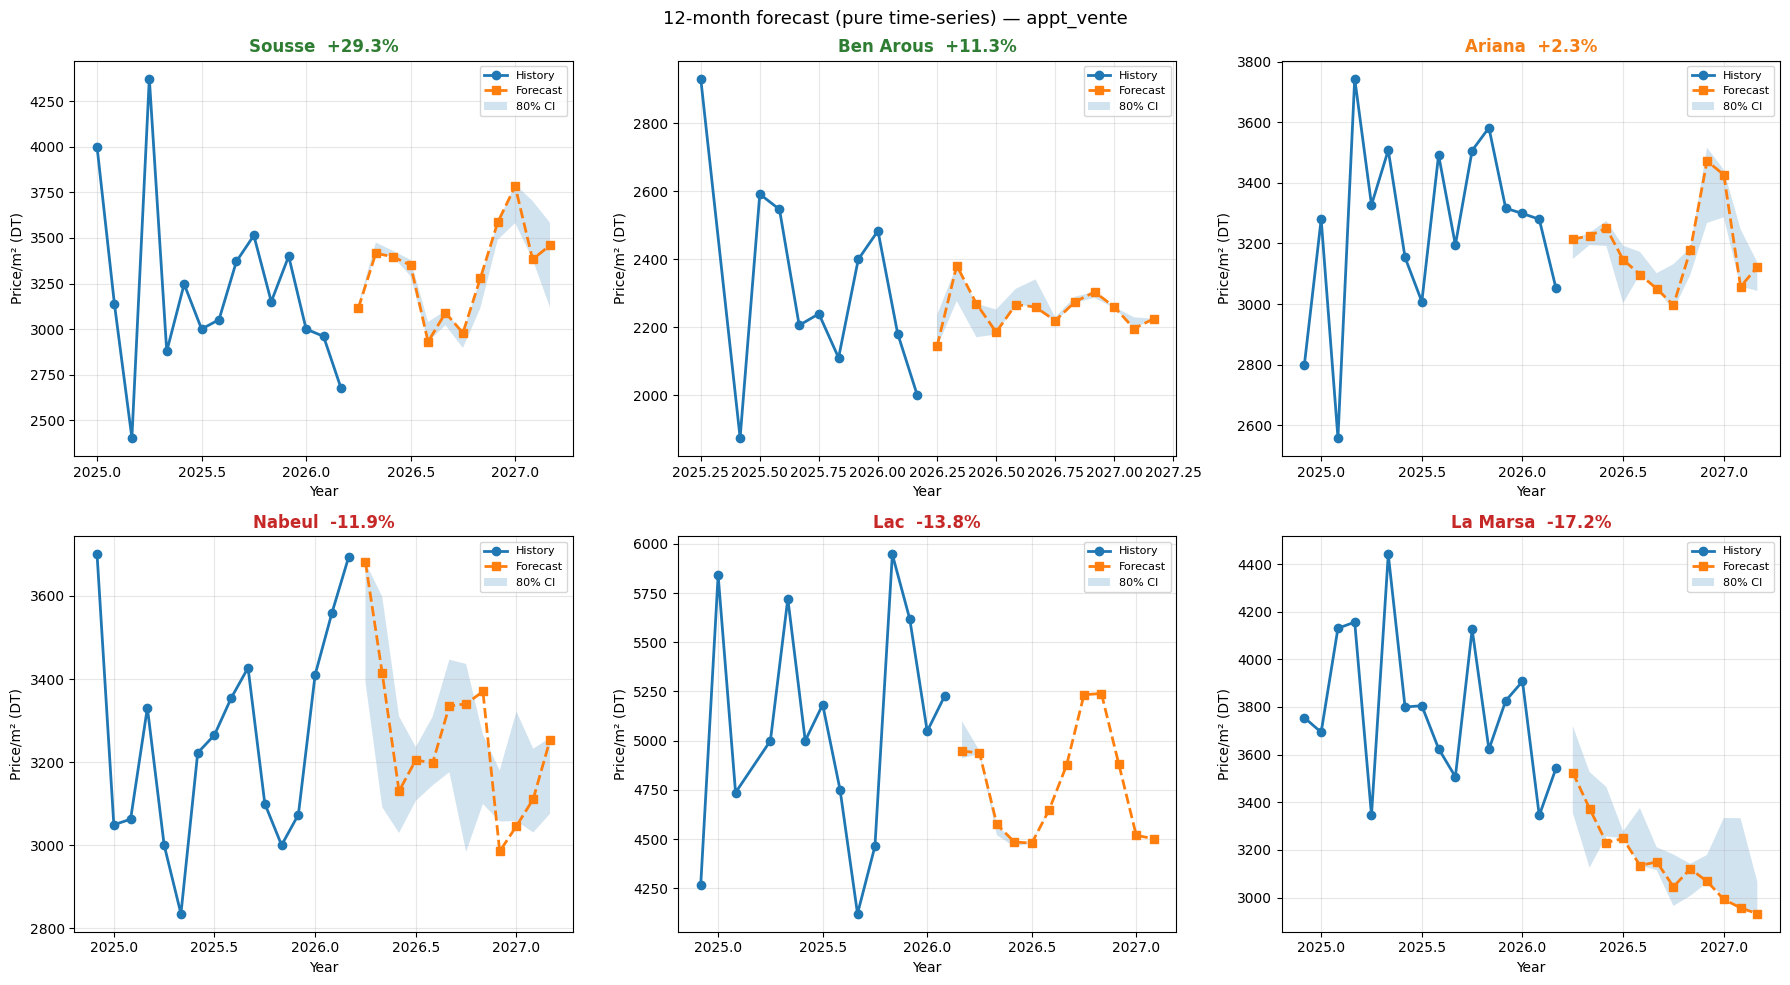


TYPE DE BIEN : APPT_LOCATION
Loaded: 7,250 rows, 82 cols
Target: median monthly rent (DT)
Panel (≥3 listings/mo): 139 rows, 14 governorates

Temporal cross-validation (5 folds):
  Fold 1: cutoff=2025-07  n_val=21  MAPE=25.2%
  Fold 2: cutoff=2025-08  n_val=23  MAPE=29.1%
  Fold 3: cutoff=2025-09  n_val=26  MAPE=38.9%
  Fold 4: cutoff=2025-10  n_val=30  MAPE=37.6%
  Fold 5: cutoff=2025-12  n_val=18  MAPE=17.9%
  → CV MAPE final : 29.7% ± 7.8%
  Final model saved: ts_model_appt_location.pkl

  Top 10 features:
mom_1m              1026
lag_1_price          751
vol_6m               686
lag_2_price          658
rolling_6_price      632
mom_3m               535
month_cos            437
month_sin            435
lag_3_price          425
rolling_12_price     396

Trend scores (7 governorates):
governorate  last_actual_price  forecast_12m_pct_change trend_direction
     Sousse             1100.0                28.762844          hausse
  Ben Arous              725.0                19.968748    

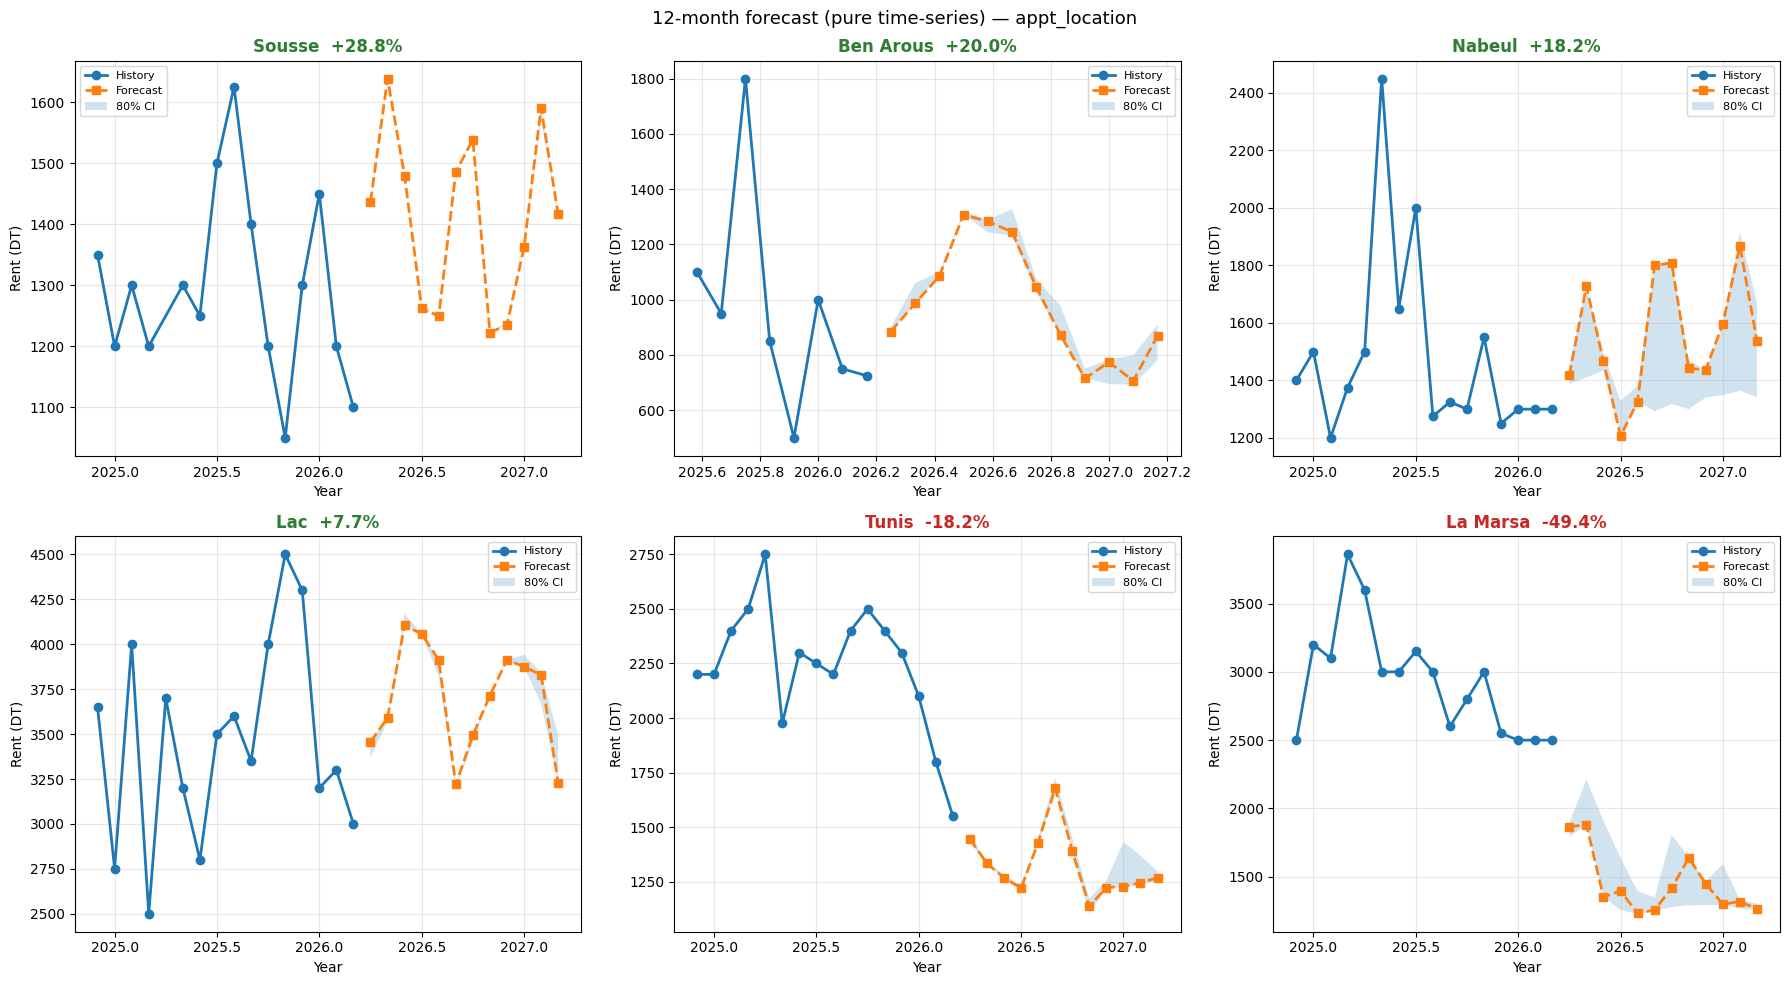


TYPE DE BIEN : MAISON_VENTE
Loaded: 2,636 rows, 82 cols
Target: median price per m² (DT/m²)
Panel (≥3 listings/mo): 153 rows, 16 governorates

Temporal cross-validation (5 folds):
  Fold 1: cutoff=2025-07  n_val=29  MAPE=14.3%
  Fold 2: cutoff=2025-08  n_val=30  MAPE=17.4%
  Fold 3: cutoff=2025-09  n_val=28  MAPE=18.6%
  Fold 4: cutoff=2025-10  n_val=28  MAPE=35.2%
  Fold 5: cutoff=2025-12  n_val=15  MAPE=43.3%
  → CV MAPE final : 25.8% ± 11.4%
  Final model saved: ts_model_maison_vente.pkl

  Top 10 features:
mom_1m              1013
lag_3_price          834
vol_6m               661
rolling_3_price      628
lag_1_price          610
mom_3m               600
lag_2_price          585
gov_encoded          585
rolling_6_price      455
rolling_12_price     426

Trend scores (8 governorates):
governorate  last_actual_price  forecast_12m_pct_change trend_direction
     Sousse        1538.461538                57.266743          hausse
    Bizerte        1677.637736                47.974379  

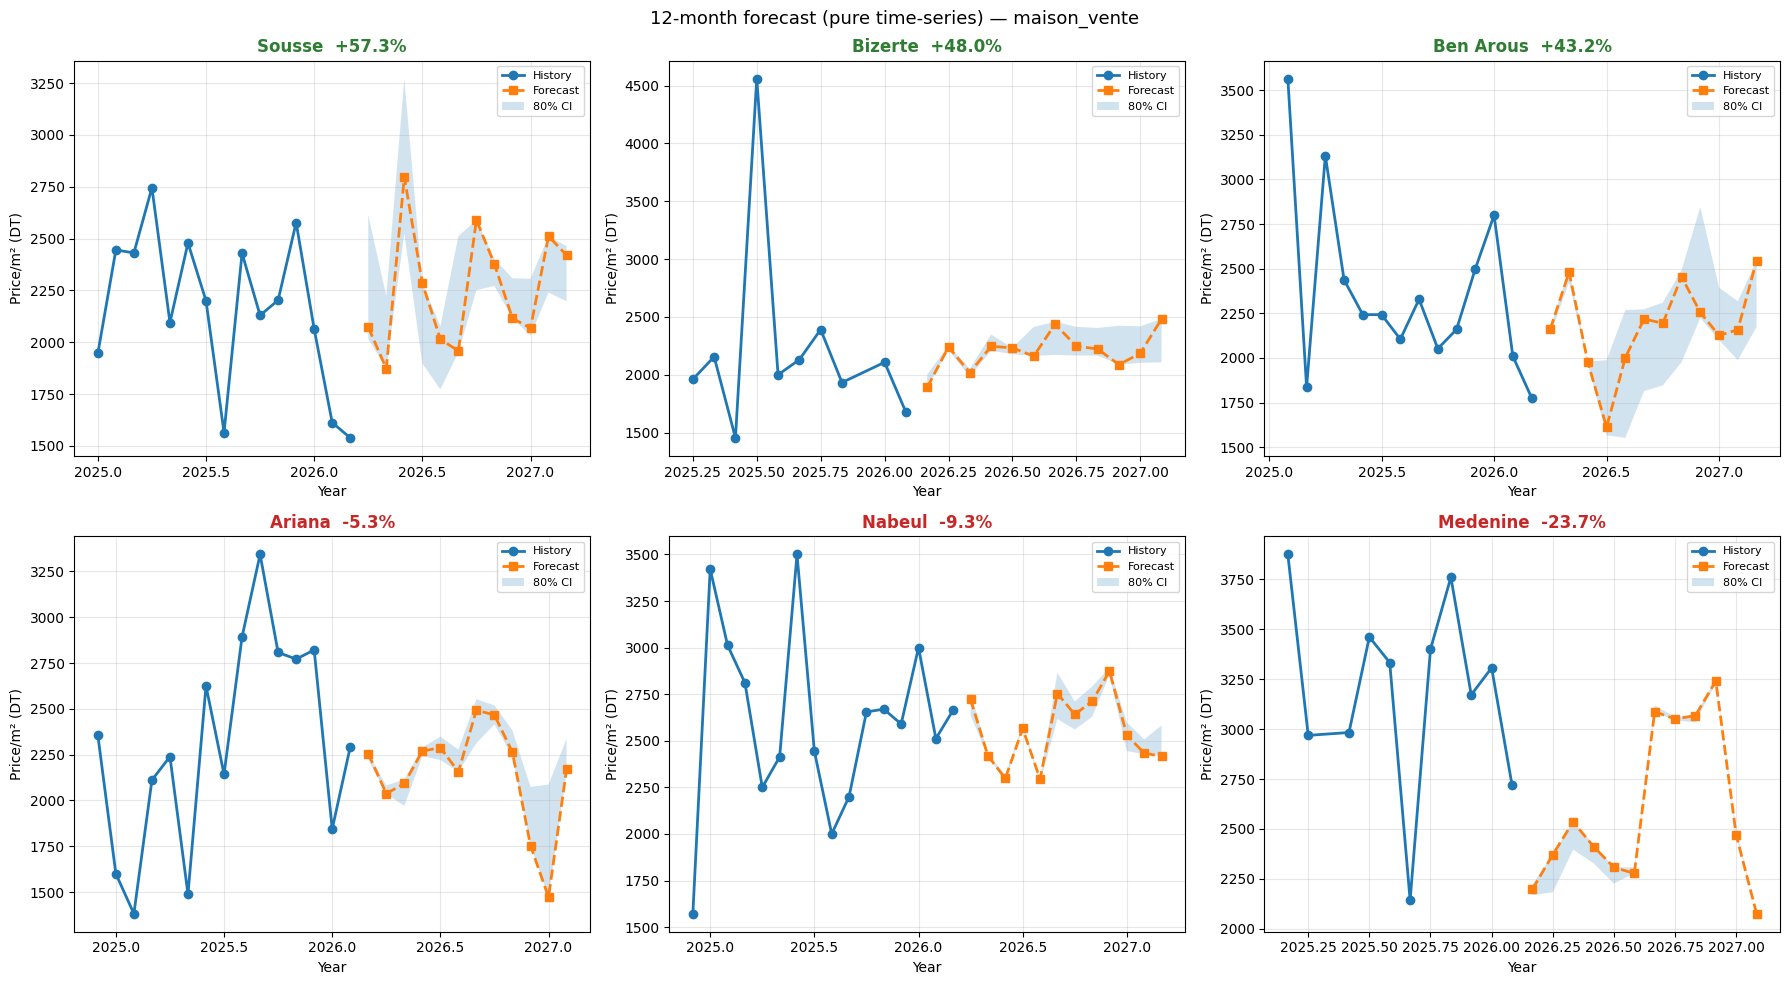


TYPE DE BIEN : MAISON_LOCATION
Loaded: 1,105 rows, 82 cols
Target: median monthly rent (DT)
Panel (≥3 listings/mo): 86 rows, 10 governorates

Temporal cross-validation (5 folds):
  Fold 1: cutoff=2025-07  n_val=18  MAPE=55.9%
  Fold 2: cutoff=2025-08  n_val=20  MAPE=39.9%
  Fold 3: cutoff=2025-09  n_val=19  MAPE=40.3%
  Fold 4: cutoff=2025-10  n_val=20  MAPE=52.1%
  Fold 5: cutoff=2025-12  n_val=10  MAPE=14.6%
  → CV MAPE final : 40.5% ± 14.4%
  Final model saved: ts_model_maison_location.pkl

  Top 10 features:
mom_1m             676
vol_6m             535
mom_3m             403
lag_2_price        371
lag_3_price        264
month_sin          251
gov_encoded        235
lag_1_price        228
rolling_3_price    226
rolling_6_price    209

Trend scores (5 governorates):
governorate  last_actual_price  forecast_12m_pct_change trend_direction
     Nabeul             2500.0                65.960700          hausse
     Ariana             2650.0                 5.563435          hausse
   

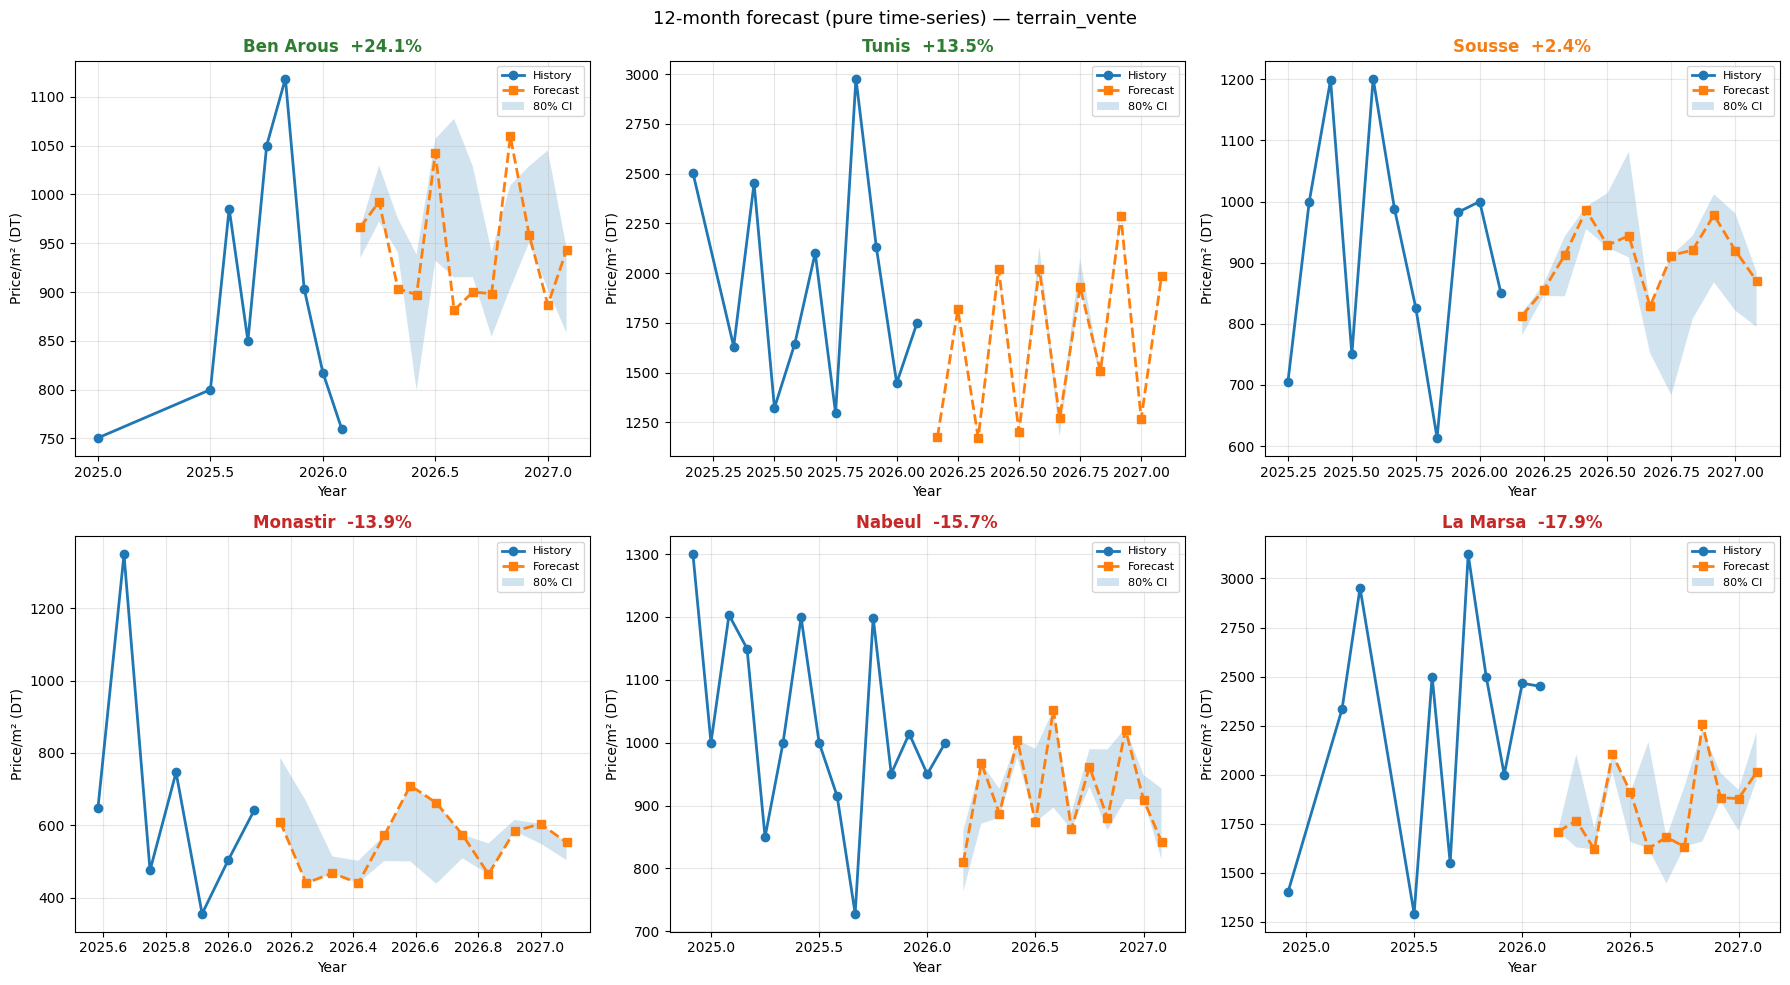


TYPE DE BIEN : LOCAL_VENTE
Loaded: 440 rows, 82 cols
Target: median price per m² (DT/m²)
Panel (≥3 listings/mo): 52 rows, 8 governorates

Temporal cross-validation (5 folds):
  Fold 1: cutoff=2025-08  n_val=13  MAPE=33.2%
  Fold 2: cutoff=2025-09  n_val=15  MAPE=26.7%
  Fold 3: cutoff=2025-10  n_val=13  MAPE=42.2%
  Fold 4: cutoff=2025-11  n_val=9  MAPE=32.7%
  Fold 5: cutoff=2025-12  n_val=4  MAPE=61.6%
  → CV MAPE final : 39.3% ± 12.2%
  Final model saved: ts_model_local_vente.pkl

  Top 10 features:
month_sin          303
lag_2_price        251
mom_1m             229
month_cos          222
lag_1_price        216
vol_6m             152
gov_encoded        144
rolling_6_price    134
lag_3_price        132
rolling_3_price     94

Trend scores (3 governorates):
governorate  last_actual_price  forecast_12m_pct_change trend_direction
     Sousse        1960.000000                60.000000          hausse
      Tunis        2978.723404               -11.967779          baisse
   La Marsa  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  clean_appt_location.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ts_trend_scores_maison_vente.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ts_trend_scores_terrain_vente.csv
Done.


In [ ]:
# ============================================================================
# TIME-SERIES-ONLY FORECASTING PIPELINE (no external data)
# Uses clean_*.csv files already saved by preprocessing
# ============================================================================

import re
import numpy as np
import pandas as pd
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

print('\n' + '='*70)
print('TIME-SERIES-ONLY FORECASTING PIPELINE')
print('(No external data: only lags, momentum, seasonality)')
print('='*70)

# ── Path to your preprocessed files (from CONFIG['output_dir']) ──────────────
# Your preprocessing already saved clean_*.csv to this location:
DATA_PATH = CONFIG['output_dir']  # '/content/kadastra_outputs/'
os.makedirs(DATA_PATH, exist_ok=True)

# Property types that were trainable (from your preprocessing output)
property_types_ts = [name for name in datasets.keys()]  # uses the 'datasets' dict from preprocessing
print(f'\nProperty types to process: {property_types_ts}')

# ── Helper functions ─────────────────────────────────────────────────────────
def clean_column_names_ts(df):
    df.columns = [re.sub(r'[^a-z0-9_]', '_', c.strip().lower()) for c in df.columns]
    return df

GOV_ALIASES_TS = {
    'ben_arous': 'Ben Arous', 'benarous': 'Ben Arous',
    'ariana': 'Ariana', 'tunis': 'Tunis',
    'sousse': 'Sousse', 'nabeul': 'Nabeul',
    'monastir': 'Monastir', 'sfax': 'Sfax',
    'bizerte': 'Bizerte', 'medenine': 'Medenine',
    'la_marsa': 'La Marsa', 'lamarsa': 'La Marsa',
    'lac': 'Lac', 'manouba': 'Manouba',
    'gabes': 'Gabes', 'gafsa': 'Gafsa',
    'beja': 'Beja', 'jendouba': 'Jendouba',
    'kairouan': 'Kairouan', 'kasserine': 'Kasserine',
    'kebili': 'Kebili', 'kef': 'Kef',
    'mahdia': 'Mahdia', 'sidi_bouzid': 'Sidi Bouzid',
    'siliana': 'Siliana', 'tataouine': 'Tataouine',
    'tozeur': 'Tozeur', 'zaghouan': 'Zaghouan',
}

def normalise_governorate_ts(val):
    if pd.isna(val):
        return 'Unknown'
    key = re.sub(r'[^a-z]', '_', str(val).strip().lower()).strip('_')
    return GOV_ALIASES_TS.get(key, val.strip().title() if isinstance(val, str) else 'Unknown')

# ── Store results ───────────────────────────────────────────────────────────
ts_results = []

for prop_type in property_types_ts:
    print(f'\n{"="*70}')
    print(f'TYPE DE BIEN : {prop_type.upper()}')
    print(f'{"="*70}')

    # ── Load clean file from preprocessing output ───────────────────────────
    clean_file = os.path.join(DATA_PATH, f'clean_{prop_type}.csv')
    if not os.path.exists(clean_file):
        print(f'  ⚠️ File not found: {clean_file} — skipping.')
        continue

    listings = pd.read_csv(clean_file)
    print(f'Loaded: {listings.shape[0]:,} rows, {listings.shape[1]} cols')

    # ── Clean and prepare ───────────────────────────────────────────────────
    listings = clean_column_names_ts(listings)

    # Find governorate column
    gov_col = next((c for c in listings.columns if 'gov' in c or 'gouvernorat' in c), None)
    if not gov_col:
        print('  ⚠️ Governorate column not found — skipping.')
        continue
    listings.rename(columns={gov_col: 'governorate'}, inplace=True)
    listings['governorate'] = listings['governorate'].apply(normalise_governorate_ts)
    listings = listings[listings['governorate'] != 'Unknown']

    # Find date column
    date_col = next((c for c in listings.columns if 'date' in c), None)
    if not date_col:
        print('  ⚠️ Date column not found — skipping.')
        continue
    listings[date_col] = pd.to_datetime(listings[date_col], errors='coerce')
    listings.rename(columns={date_col: 'datepost'}, inplace=True)
    listings = listings.dropna(subset=['datepost', 'governorate', 'price_numeric'])

    # ── Target definition ───────────────────────────────────────────────────
    if 'location' in prop_type:
        listings = listings[(listings['price_numeric'] >= 200) & (listings['price_numeric'] <= 20000)]
        target_col = 'price_numeric'
        print('Target: median monthly rent (DT)')
    else:
        surf_col = next((c for c in listings.columns if 'surface' in c), None)
        if not surf_col:
            print('  ⚠️ Surface column not found — skipping.')
            continue
        listings['prix_m2'] = listings['price_numeric'] / listings[surf_col].replace(0, np.nan)
        listings = listings[(listings['prix_m2'] >= 200) & (listings['prix_m2'] <= 15000)]
        target_col = 'prix_m2'
        print('Target: median price per m² (DT/m²)')

    listings['year'] = listings['datepost'].dt.year
    listings['month'] = listings['datepost'].dt.month

    # ── Build panel (governorate × month) ───────────────────────────────────
    panel = listings.groupby(['governorate', 'year', 'month']).agg(
        median_price=(target_col, 'median'),
        n_listings=(target_col, 'count')
    ).reset_index().rename(columns={'median_price': 'median_prix_m2'})

    panel = panel[panel['n_listings'] >= 3]
    print(f'Panel (≥3 listings/mo): {panel.shape[0]} rows, {panel["governorate"].nunique()} governorates')

    # ── PURE TIME-SERIES FEATURES (no external merges) ──────────────────────
    panel = panel.sort_values(['governorate', 'year', 'month']).reset_index(drop=True)

    # Lags (1, 2, 3, 6, 12 months)
    for lag in [1, 2, 3, 6, 12]:
        panel[f'lag_{lag}_price'] = panel.groupby('governorate')['median_prix_m2'].shift(lag)

    # Rolling means (using lagged values only)
    for window in [3, 6, 12]:
        panel[f'rolling_{window}_price'] = (
            panel.groupby('governorate')['median_prix_m2']
            .apply(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
            .reset_index(level=0, drop=True)
        )

    # Momentum (percentage changes)
    panel['mom_1m'] = panel.groupby('governorate')['median_prix_m2'].pct_change(1, fill_method=None)
    panel['mom_3m'] = panel.groupby('governorate')['median_prix_m2'].pct_change(3, fill_method=None)
    panel['mom_12m'] = panel.groupby('governorate')['median_prix_m2'].pct_change(12, fill_method=None)

    # Rolling volatility (std dev over 6 months)
    panel['vol_6m'] = (
        panel.groupby('governorate')['median_prix_m2']
        .apply(lambda x: x.shift(1).rolling(6, min_periods=2).std())
        .reset_index(level=0, drop=True)
    )

    # Seasonal cycles (sin/cos — avoids ordinal month)
    panel['month_sin'] = np.sin(2 * np.pi * panel['month'] / 12)
    panel['month_cos'] = np.cos(2 * np.pi * panel['month'] / 12)

    # Governorate encoding
    gov_map = {g: i for i, g in enumerate(panel['governorate'].unique())}
    panel['gov_encoded'] = panel['governorate'].map(gov_map)

    # Global time trend
    panel['time_idx'] = panel['year'] * 12 + panel['month']
    min_t = panel['time_idx'].min()
    panel['trend_t'] = panel['time_idx'] - min_t

    # ── Target (next month's price) ─────────────────────────────────────────
    panel['target'] = panel.groupby('governorate')['median_prix_m2'].shift(-1)
    panel = panel.dropna(subset=['target', 'lag_1_price'])

    panel = panel.sort_values(['year', 'month', 'governorate']).reset_index(drop=True)

    # ── Feature columns ─────────────────────────────────────────────────────
    exclude = ['governorate', 'year', 'month', 'median_prix_m2', 'target',
               'n_listings', 'time_idx']
    feature_cols = [c for c in panel.columns
                    if c not in exclude and panel[c].dtype in ['float64', 'int64']]

    X = panel[feature_cols].copy()
    y = panel['target'].copy()

    # Sanitize column names for LightGBM
    san_map = {col: re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in feature_cols}
    X.rename(columns=san_map, inplace=True)
    feature_cols_clean = list(san_map.values())
    panel.rename(columns=san_map, inplace=True)

    global_medians = X.median()

    # ── Temporal cross-validation (5 folds) ─────────────────────────────────
    unique_times = sorted(panel['time_idx'].unique())
    n_times = len(unique_times)
    mape_scores = []
    print('\nTemporal cross-validation (5 folds):')

    for fold in range(5):
        cidx = int(n_times * (0.5 + fold * 0.08))
        if cidx >= n_times - 1:
            print(f'  Fold {fold+1}: skipped (insufficient data)')
            continue
        cutoff = unique_times[cidx]
        yc, mc = cutoff // 12, cutoff % 12
        if mc == 0:
            yc -= 1
            mc = 12

        train_mask = panel['time_idx'] <= cutoff
        val_mask = (panel['time_idx'] > cutoff) & (panel['time_idx'] <= cutoff + 3)

        if val_mask.sum() == 0:
            continue

        tm = X[train_mask].median()
        Xtr = X[train_mask].fillna(tm)
        ytr = y[train_mask]
        Xvl = X[val_mask].fillna(tm)
        yvl = y[val_mask]

        model = lgb.LGBMRegressor(
            n_estimators=300, learning_rate=0.05,
            num_leaves=31, min_child_samples=5,
            random_state=42, verbose=-1
        )
        model.fit(Xtr, ytr,
                  eval_set=[(Xvl, yvl)],
                  callbacks=[lgb.early_stopping(30, verbose=False)])

        mape = mean_absolute_percentage_error(yvl, model.predict(Xvl)) * 100
        mape_scores.append(mape)
        print(f'  Fold {fold+1}: cutoff={yc}-{mc:02d}  n_val={len(yvl)}  MAPE={mape:.1f}%')

    cv_mean = np.mean(mape_scores) if mape_scores else np.nan
    cv_std = np.std(mape_scores) if mape_scores else np.nan
    if mape_scores:
        print(f'  → CV MAPE final : {cv_mean:.1f}% ± {cv_std:.1f}%')

    # ── Final model (full training) ─────────────────────────────────────────
    final_model = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.03,
        num_leaves=31, min_child_samples=5,
        random_state=42, verbose=-1
    )
    final_model.fit(X.fillna(global_medians), y)
    joblib.dump(final_model, os.path.join(DATA_PATH, f'ts_model_{prop_type}.pkl'))
    print(f'  Final model saved: ts_model_{prop_type}.pkl')

    # Feature importance
    fi = pd.Series(final_model.feature_importances_, index=feature_cols_clean).sort_values(ascending=False)
    print('\n  Top 10 features:')
    print(fi.head(10).to_string())

    # ── 12-month forecast with bootstrap intervals ──────────────────────────
    forecasts = []
    bootstrap_forecasts = {}

    for gov in panel['governorate'].unique():
        gd = panel[panel['governorate'] == gov].sort_values(['year', 'month'])
        if len(gd) < 6:
            continue

        history = gd['median_prix_m2'].values.tolist()
        last_row = gd.iloc[-1].copy()
        cy, cm = int(last_row['year']), int(last_row['month'])

        # Bootstrap runs (50 with noise)
        runs = []
        for _ in range(50):
            hb = history.copy()
            hb[-1] *= (1 + np.random.normal(0, 0.02))
            rb = last_row.copy()
            cy_b, cm_b = cy, cm
            fb = []
            for _ in range(12):
                cm_b += 1
                if cm_b > 12:
                    cm_b = 1
                    cy_b += 1
                rb['year'] = cy_b
                rb['month'] = cm_b
                rb['lag_1_price'] = hb[-1]
                rb['lag_2_price'] = hb[-2] if len(hb) >= 2 else hb[0]
                rb['lag_3_price'] = hb[-3] if len(hb) >= 3 else hb[0]
                rb['lag_6_price'] = hb[-6] if len(hb) >= 6 else hb[0]
                rb['lag_12_price'] = hb[-12] if len(hb) >= 12 else hb[0]
                rb['rolling_3_price'] = np.mean(hb[-3:])
                rb['rolling_6_price'] = np.mean(hb[-6:]) if len(hb) >= 6 else np.mean(hb)
                rb['rolling_12_price'] = np.mean(hb[-12:]) if len(hb) >= 12 else np.mean(hb)
                rb['mom_1m'] = (hb[-1] - hb[-2]) / hb[-2] if len(hb) >= 2 and hb[-2] != 0 else 0
                rb['mom_3m'] = (hb[-1] - hb[-3]) / hb[-3] if len(hb) >= 3 and hb[-3] != 0 else 0
                rb['mom_12m'] = (hb[-1] - hb[-12]) / hb[-12] if len(hb) >= 12 and hb[-12] != 0 else 0
                rb['vol_6m'] = np.std(hb[-6:]) if len(hb) >= 6 else 0
                rb['month_sin'] = np.sin(2 * np.pi * cm_b / 12)
                rb['month_cos'] = np.cos(2 * np.pi * cm_b / 12)
                rb['trend_t'] += 1
                feat_row = pd.DataFrame([rb[feature_cols_clean]]).fillna(global_medians)
                pp = final_model.predict(feat_row)[0]
                hb.append(pp)
                fb.append(pp)
            runs.append(fb)

        # Deterministic forecast
        hbase = history.copy()
        rbase = last_row.copy()
        cy_b, cm_b = cy, cm
        for step in range(12):
            cm_b += 1
            if cm_b > 12:
                cm_b = 1
                cy_b += 1
            rbase['year'] = cy_b
            rbase['month'] = cm_b
            rbase['lag_1_price'] = hbase[-1]
            rbase['lag_2_price'] = hbase[-2] if len(hbase) >= 2 else hbase[0]
            rbase['lag_3_price'] = hbase[-3] if len(hbase) >= 3 else hbase[0]
            rbase['lag_6_price'] = hbase[-6] if len(hbase) >= 6 else hbase[0]
            rbase['lag_12_price'] = hbase[-12] if len(hbase) >= 12 else hbase[0]
            rbase['rolling_3_price'] = np.mean(hbase[-3:])
            rbase['rolling_6_price'] = np.mean(hbase[-6:]) if len(hbase) >= 6 else np.mean(hbase)
            rbase['rolling_12_price'] = np.mean(hbase[-12:]) if len(hbase) >= 12 else np.mean(hbase)
            rbase['mom_1m'] = (hbase[-1] - hbase[-2]) / hbase[-2] if len(hbase) >= 2 and hbase[-2] != 0 else 0
            rbase['mom_3m'] = (hbase[-1] - hbase[-3]) / hbase[-3] if len(hbase) >= 3 and hbase[-3] != 0 else 0
            rbase['mom_12m'] = (hbase[-1] - hbase[-12]) / hbase[-12] if len(hbase) >= 12 and hbase[-12] != 0 else 0
            rbase['vol_6m'] = np.std(hbase[-6:]) if len(hbase) >= 6 else 0
            rbase['month_sin'] = np.sin(2 * np.pi * cm_b / 12)
            rbase['month_cos'] = np.cos(2 * np.pi * cm_b / 12)
            rbase['trend_t'] += 1
            feat_row = pd.DataFrame([rbase[feature_cols_clean]]).fillna(global_medians)
            pp = final_model.predict(feat_row)[0]
            hbase.append(pp)
            forecasts.append({
                'governorate': gov,
                'year': cy_b,
                'month': cm_b,
                'forecast_prix_m2': pp,
                'is_forecast': True
            })
        bootstrap_forecasts[gov] = np.array(runs)

    # ── Trend scores ────────────────────────────────────────────────────────
    forecast_df = pd.DataFrame(forecasts)
    trend_scores = []

    for gov in forecast_df['governorate'].unique():
        sub = forecast_df[forecast_df['governorate'] == gov].reset_index(drop=True)
        last = panel[panel['governorate'] == gov]['median_prix_m2'].iloc[-1]
        fc12 = sub['forecast_prix_m2'].iloc[-1]
        pct = (fc12 - last) / last * 100

        if prop_type in ['terrain_vente', 'maison_vente', 'local_vente']:
            pct = np.clip(pct, -60, 60)

        trend_scores.append({
            'governorate': gov,
            'last_actual_price': last,
            'forecast_12m_price': fc12,
            'forecast_12m_pct_change': pct,
            'trend_direction': 'hausse' if pct > 5 else ('baisse' if pct < -5 else 'stable')
        })

    trend_df = pd.DataFrame(trend_scores).sort_values('forecast_12m_pct_change', ascending=False)
    trend_df.to_csv(os.path.join(DATA_PATH, f'ts_trend_scores_{prop_type}.csv'), index=False)

    print(f'\nTrend scores ({len(trend_df)} governorates):')
    print(trend_df[['governorate', 'last_actual_price', 'forecast_12m_pct_change', 'trend_direction']].to_string(index=False))

    # ── Forecast plots ──────────────────────────────────────────────────────
    if len(trend_df) >= 6:
        top3 = trend_df.head(3)['governorate'].tolist()
        bot3 = trend_df.tail(3)['governorate'].tolist()
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'12-month forecast (pure time-series) — {prop_type}', fontsize=13)
        axes = axes.flatten()

        for i, gov in enumerate(top3 + bot3):
            ax = axes[i]
            hist = panel[panel['governorate'] == gov].sort_values(['year', 'month'])
            ax.plot(hist['year'] + hist['month'] / 12, hist['median_prix_m2'],
                    'o-', label='History', linewidth=2)
            fc = forecast_df[forecast_df['governorate'] == gov].sort_values(['year', 'month'])
            fc_x = fc['year'] + fc['month'] / 12
            ax.plot(fc_x, fc['forecast_prix_m2'], 's--', label='Forecast', linewidth=2)

            if gov in bootstrap_forecasts:
                ci_lo = np.percentile(bootstrap_forecasts[gov], 10, axis=0)
                ci_hi = np.percentile(bootstrap_forecasts[gov], 90, axis=0)
                ax.fill_between(fc_x, ci_lo, ci_hi, alpha=0.2, label='80% CI')

            pct_val = trend_df[trend_df['governorate'] == gov]['forecast_12m_pct_change'].values
            pct_str = f'{pct_val[0]:+.1f}%' if len(pct_val) > 0 else ''
            color = ('#2E7D32' if (len(pct_val) > 0 and pct_val[0] > 5)
                     else ('#C62828' if (len(pct_val) > 0 and pct_val[0] < -5) else '#F57F17'))
            ax.set_title(f'{gov}  {pct_str}', color=color, fontweight='bold')
            ax.set_xlabel('Year')
            ax.set_ylabel('Price/m² (DT)' if 'vente' in prop_type else 'Rent (DT)')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(DATA_PATH, f'ts_forecast_{prop_type}.png'), dpi=100)
        plt.show()
        plt.close()

    # ── Store results ───────────────────────────────────────────────────────
    ts_results.append({
        'property_type': prop_type,
        'n_panel_rows': len(panel),
        'cv_mape_mean': cv_mean,
        'cv_mape_std': cv_std,
        'n_governorates_forecast': len(trend_df),
        'reliable': cv_mean < 35 and len(panel) > 50,
        'n_features': len(feature_cols_clean),
    })

# ── Summary comparison with external-feature version ────────────────────────
print('\n' + '='*70)
print('SUMMARY — TIME-SERIES-ONLY PIPELINE')
print('='*70)

ts_results_df = pd.DataFrame(ts_results)
print(ts_results_df[['property_type', 'n_features', 'cv_mape_mean', 'cv_mape_std',
                      'n_governorates_forecast', 'reliable']].to_string(index=False))

# Compare with the external-feature CV results (from earlier in your notebook)
print('\n' + '='*70)
print('COMPARISON: External features (LGBM from training section) vs TS‑only')
print('='*70)

# These values come from your earlier model training output
external_cv = {
    'appt_vente': 19.4,
    'appt_location': 21.1,
    'maison_vente': 32.7,
    'maison_location': 30.9,
    'terrain_vente': 42.0,
    'local_vente': 44.8,
}

print(f'\n  {"Type":<20} {"Ext. CV MAPE":>14} {"TS CV MAPE":>14} {"Δ":>8} {"Conclusion":>12}')
print('  ' + '-'*70)

for _, row in ts_results_df.iterrows():
    pt = row['property_type']
    ext = external_cv.get(pt, np.nan)
    ts = row['cv_mape_mean']
    delta = ts - ext if not np.isnan(ext) else np.nan

    if np.isnan(ext):
        conclusion = 'N/A (no external)'
    elif delta < -3:
        conclusion = '✅ TS better'
    elif delta > 3:
        conclusion = '❌ TS worse'
    else:
        conclusion = '≈ Similar'

    ext_str = f'{ext:.1f}%' if not np.isnan(ext) else 'N/A'
    ts_str = f'{ts:.1f}%' if not np.isnan(ts) else 'N/A'
    delta_str = f'{delta:+.1f}%' if not np.isnan(delta) else 'N/A'

    print(f'  {pt:<20} {ext_str:>14} {ts_str:>14} {delta_str:>8} {conclusion:>12}')

print('\n✅ Time-series-only pipeline complete.')
print(f'   All outputs saved to: {DATA_PATH}')
print('   Files: ts_model_*.pkl, ts_trend_scores_*.csv, ts_forecast_*.png')

# ============================================================================
# DOWNLOAD ALL GENERATED FILES TO YOUR PC
# ============================================================================
print('\nDownloading all outputs...')
from google.colab import files
for fname in sorted(os.listdir(DATA_PATH)):
    path = os.path.join(DATA_PATH, fname)
    if os.path.isfile(path):
        files.download(path)
        print(f'  {fname}')
print('Done.')